In [ ]:
import matplotlib
matplotlib.use('Agg')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import io, warnings, itertools
warnings.filterwarnings('ignore')
from IPython.display import display, Image as IPImage
from sklearn.datasets import fetch_openml

In [ ]:
pip install qiskit qiskit-aer qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.8 MB/s eta 0:00:00


In [ ]:
def show_inline(fig, caption=""):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)
    if caption:
        print(f"  ↑ {caption}\n")

def plot_cm(cm, classes, title, ax, cmap=plt.cm.Blues):
    ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title, fontsize=10)
    ticks = np.arange(len(classes))
    ax.set_xticks(ticks); ax.set_xticklabels(classes)
    ax.set_yticks(ticks); ax.set_yticklabels(classes)
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > thresh else 'black')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')


In [ ]:
LC_N_QUBITS      = 4
LC_N_PCA         = 4
LC_N_SHOTS       = 2048
LC_LABEL_NOISE   = 0.05
LC_FEATURE_NOISE = 0.05
LC_RANDOM_SEED   = 42
LC_C_GRID        = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
np.random.seed(LC_RANDOM_SEED)

print("=" * 58)
print("UCI Lung Cancer: Load & EDA")
print("=" * 58)


UCI Lung Cancer: Load & EDA



Loading UCI Lung Cancer (id=62) via fetch_openml …
✓ Loaded   : 32 samples × 56 features
  Classes  : [1, 2, 3]  counts = {np.int64(1): np.int64(9), np.int64(2): np.int64(13), np.int64(3): np.int64(10)}
  Missing  : 5 cells in columns: ['attribute5', 'attribute39']


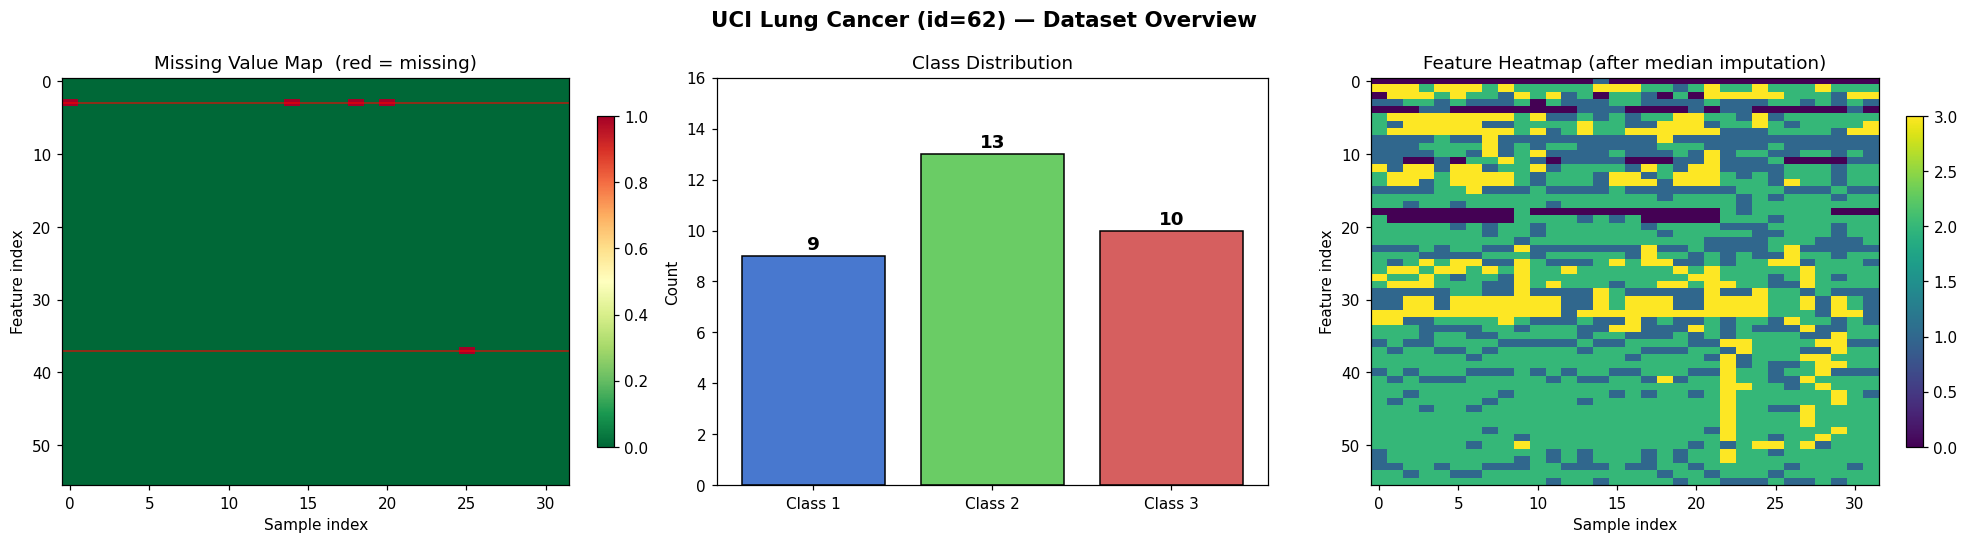

  ↑ Dataset: missing value map | class distribution | feature heatmap

 32 samples, 56 features, 3 classes


In [ ]:
print("\nLoading UCI Lung Cancer (id=62) via fetch_openml …")
raw = fetch_openml(name='lung-cancer', version=1, as_frame=True, parser='auto')
X_df = raw.data.copy()
y_s  = raw.target.copy()

y_vals = pd.to_numeric(y_s, errors='coerce')
if y_vals.isna().all():
    y_vals = y_s.cat.codes.astype(float) + 1
y_raw_vals = y_vals.values.astype(int)

for col in X_df.columns:
    X_df[col] = pd.to_numeric(X_df[col], errors='coerce')

print(f"✓ Loaded   : {X_df.shape[0]} samples × {X_df.shape[1]} features")
print(f"  Classes  : {np.unique(y_raw_vals).tolist()}  "
      f"counts = {dict(zip(*np.unique(y_raw_vals, return_counts=True)))}")

missing_mask = X_df.isna()
missing_cols = missing_mask.any(axis=0)
print(f"  Missing  : {int(missing_mask.sum().sum())} cells "
      f"in columns: {list(X_df.columns[missing_cols])}")

# Impute with column median
X_filled = X_df.copy()
for col in X_filled.columns:
    X_filled[col] = X_filled[col].fillna(X_filled[col].median())
X_filled = X_filled.astype(float)

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("UCI Lung Cancer (id=62) — Dataset Overview",
             fontsize=14, fontweight='bold')

ax = axes[0]
im = ax.imshow(missing_mask.T.astype(int), aspect='auto',
               cmap='RdYlGn_r', interpolation='nearest')
ax.set_xlabel("Sample index"); ax.set_ylabel("Feature index")
ax.set_title("Missing Value Map  (red = missing)")
plt.colorbar(im, ax=ax, fraction=0.03)
for ci in np.where(missing_cols)[0]:
    ax.axhline(ci, color='red', linewidth=1.0, alpha=0.7)

ax = axes[1]
uniq, cnts = np.unique(y_raw_vals, return_counts=True)
bars = ax.bar([f"Class {u}" for u in uniq], cnts,
              color=['#4878CF', '#6ACC65', '#D65F5F'], edgecolor='k')
ax.set_ylabel("Count"); ax.set_title("Class Distribution")
ax.set_ylim(0, max(cnts) + 3)
for b, v in zip(bars, cnts):
    ax.text(b.get_x() + b.get_width()/2, v + 0.1, str(v),
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax = axes[2]
im2 = ax.imshow(X_filled.values.T, aspect='auto',
                cmap='viridis', interpolation='nearest')
ax.set_xlabel("Sample index"); ax.set_ylabel("Feature index")
ax.set_title("Feature Heatmap (after median imputation)")
plt.colorbar(im2, ax=ax, fraction=0.03)

plt.tight_layout()
show_inline(fig, "Dataset: missing value map | class distribution | feature heatmap")

# ── Globals ───────────────────────────────────────────────────
LC_X_filled = X_filled
LC_y_vals   = y_raw_vals
print(" 32 samples, 56 features, 3 classes")


Class Selection + Binary Conversion + SMOTE

Evaluating binary class pairs (LOO SVM on PCA features):
  Class 1 vs 2 : 0.5455  (n=22)
  Class 1 vs 3 : 0.9474  (n=19)
  Class 2 vs 3 : 0.8261  (n=23)

✓ Best split : Class 1 vs Class 3  (LOO acc = 0.9474)
Binary subset : 19 samples  | balance: Counter({np.int64(1): 10, np.int64(0): 9})
PCA : 4 components | explained variance = 0.5404
After SMOTE : 20 samples  Counter({np.int64(0): 10, np.int64(1): 10})


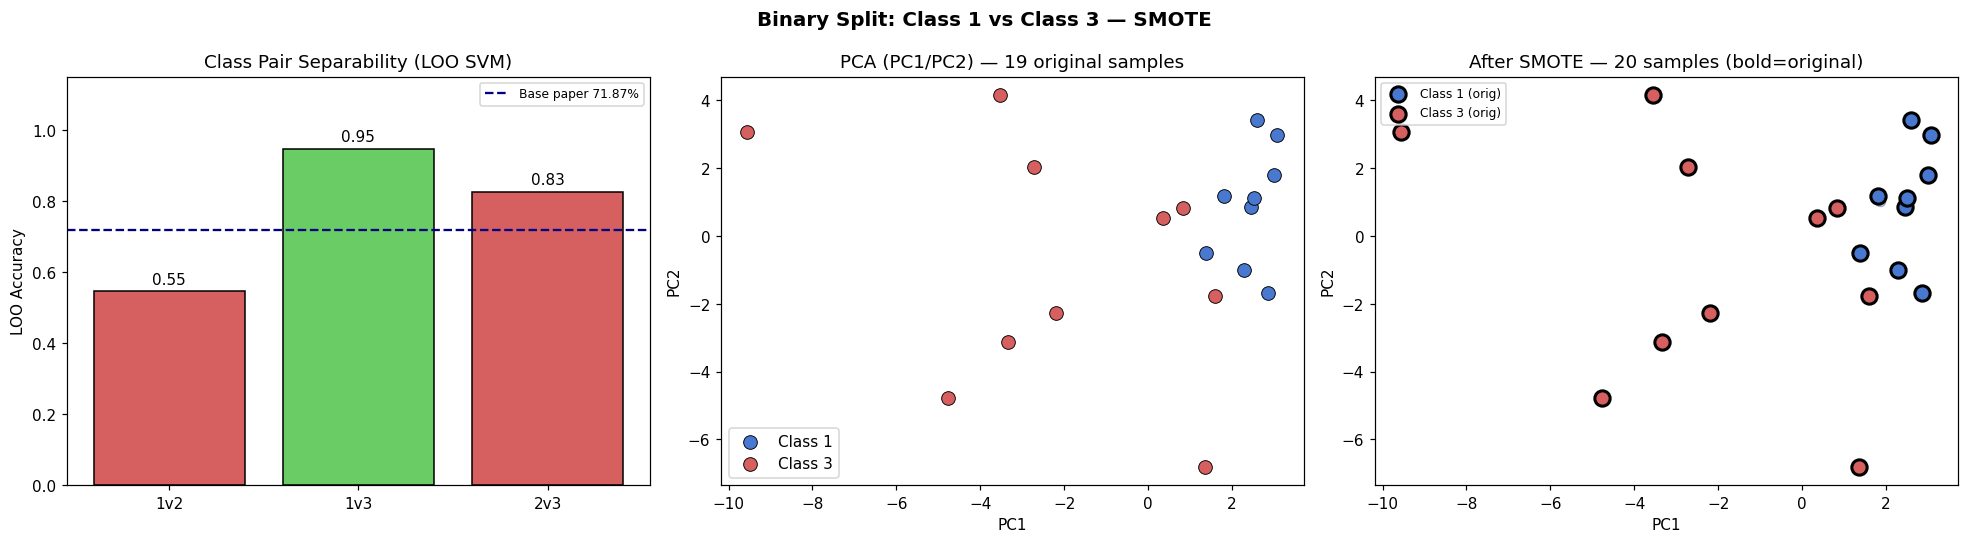

  ↑ Pair separability | PCA scatter before/after SMOTE

binary data ready, SMOTE applied.


In [ ]:
import numpy as np, matplotlib.pyplot as plt, io
from IPython.display import display, Image as IPImage
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE

print("=" * 58)
print("Class Selection + Binary Conversion + SMOTE")
print("=" * 58)

# ── Evaluate all binary pairs via LOO SVM ────────────────────
classes_all = sorted(np.unique(LC_y_vals))
pairs = [(classes_all[i], classes_all[j])
         for i in range(len(classes_all))
         for j in range(i + 1, len(classes_all))]

print("\nEvaluating binary class pairs (LOO SVM on PCA features):")
best_pair, best_score = None, -1.0
pair_scores = {}

for c1, c2 in pairs:
    mask = (LC_y_vals == c1) | (LC_y_vals == c2)
    Xp   = LC_X_filled.values[mask]
    yp   = (LC_y_vals[mask] == c2).astype(int)
    Xs   = StandardScaler().fit_transform(Xp)
    nc   = min(LC_N_PCA, Xs.shape[0] - 1, Xs.shape[1])
    Xpc  = PCA(n_components=nc, random_state=LC_RANDOM_SEED).fit_transform(Xs)
    preds = cross_val_predict(
        SVC(kernel='rbf', C=1.0, probability=True, random_state=LC_RANDOM_SEED),
        Xpc, yp, cv=LeaveOneOut())
    mu = accuracy_score(yp, preds)
    pair_scores[(c1, c2)] = mu
    print(f"  Class {c1} vs {c2} : {mu:.4f}  (n={mask.sum()})")
    if mu > best_score:
        best_score = mu; best_pair = (c1, c2)

print(f"\n✓ Best split : Class {best_pair[0]} vs Class {best_pair[1]}"
      f"  (LOO acc = {best_score:.4f})")

c1, c2   = best_pair
mask_bin  = (LC_y_vals == c1) | (LC_y_vals == c2)
X_bin_raw = LC_X_filled.values[mask_bin]
y_bin     = (LC_y_vals[mask_bin] == c2).astype(int)
print(f"Binary subset : {X_bin_raw.shape[0]} samples  "
      f"| balance: {Counter(y_bin)}")

# ── StandardScaler + PCA ─────────────────────────────────────
n_comp    = min(LC_N_PCA, X_bin_raw.shape[0] - 1, X_bin_raw.shape[1])
scaler_lc = StandardScaler()
pca_lc    = PCA(n_components=n_comp, random_state=LC_RANDOM_SEED)
X_scaled  = scaler_lc.fit_transform(X_bin_raw)
X_pca     = pca_lc.fit_transform(X_scaled)
print(f"PCA : {n_comp} components | "
      f"explained variance = {pca_lc.explained_variance_ratio_.sum():.4f}")

# ── SMOTE ─────────────────────────────────────────────────────
min_cls   = min(Counter(y_bin).values())
k_nn      = max(1, min_cls - 1)
X_smote, y_smote = SMOTE(random_state=LC_RANDOM_SEED,
                          k_neighbors=k_nn).fit_resample(X_pca, y_bin)
print(f"After SMOTE : {X_smote.shape[0]} samples  {Counter(y_smote)}")

# ── Angle encode [-π, π] ─────────────────────────────────────
def angle_encode(X, eps=1e-8):
    lo, hi = X.min(0), X.max(0)
    return ((X - lo) / (hi - lo + eps) * 2 - 1) * np.pi

X_enc_orig  = angle_encode(X_pca)
X_enc_smote = angle_encode(X_smote)

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Binary Split: Class {c1} vs Class {c2} — SMOTE",
             fontsize=13, fontweight='bold')

ax = axes[0]
plabs = [f"{p[0]}v{p[1]}" for p in pairs]
pvals = [pair_scores[p] for p in pairs]
pcols = ['#6ACC65' if p == best_pair else '#D65F5F' for p in pairs]
bars  = ax.bar(plabs, pvals, color=pcols, edgecolor='k')
ax.set_ylim(0, 1.15); ax.set_ylabel("LOO Accuracy")
ax.set_title("Class Pair Separability (LOO SVM)")
ax.axhline(0.7187, color='navy', linestyle='--', label='Base paper 71.87%')
ax.legend(fontsize=8)
for b, v in zip(bars, pvals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02,
            f"{v:.2f}", ha='center', fontsize=10)

ax = axes[1]
for lbl, col in zip([0, 1], ['#4878CF', '#D65F5F']):
    m = y_bin == lbl
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=col, edgecolors='k',
               s=80, linewidth=0.6, label=f"Class {[c1,c2][lbl]}")
ax.set_title(f"PCA (PC1/PC2) — {X_pca.shape[0]} original samples")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()

ax = axes[2]
for lbl, col in zip([0, 1], ['#4878CF', '#D65F5F']):
    ms = y_smote == lbl
    ax.scatter(X_smote[ms, 0], X_smote[ms, 1],
               c=col, alpha=0.45, edgecolors='k', linewidth=0.3, s=50)
for lbl, col in zip([0, 1], ['#4878CF', '#D65F5F']):
    mo = y_bin == lbl
    ax.scatter(X_pca[mo, 0], X_pca[mo, 1], c=col, edgecolors='black',
               linewidth=2.0, s=100, zorder=5,
               label=f"Class {[c1,c2][lbl]} (orig)")
ax.set_title(f"After SMOTE — {X_smote.shape[0]} samples (bold=original)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8)

plt.tight_layout()
show_inline(fig, "Pair separability | PCA scatter before/after SMOTE")

# ── Globals ───────────────────────────────────────────────────
LC_CLASSES      = best_pair
LC_X_bin        = X_bin_raw
LC_y_bin        = y_bin
LC_X_pca        = X_pca
LC_X_smote      = X_smote
LC_y_smote      = y_smote
LC_X_enc_orig   = X_enc_orig
LC_X_enc_smote  = X_enc_smote
LC_scaler_lc    = scaler_lc
LC_pca_lc       = pca_lc
LC_n_comp       = n_comp
CLASS_LABELS    = [f"C{best_pair[0]}", f"C{best_pair[1]}"]
print("binary data ready, SMOTE applied.")



 Classical SVM Baseline (LOO CV)

C grid (SMOTE 5-fold):
  C=  0.01 : 0.9000 ± 0.1225 ←
  C=  0.10 : 0.9000 ± 0.1225
  C=  0.50 : 0.9000 ± 0.1225
  C=  1.00 : 0.9500 ± 0.1000 ←
  C=  5.00 : 0.9500 ± 0.1000
  C= 10.00 : 0.9000 ± 0.1225
  C= 50.00 : 0.9000 ± 0.1225

✓ SVM LOO (C=1.0) : 0.9474  (94.74%)

              precision    recall  f1-score   support

          C1       1.00      0.89      0.94         9
          C3       0.91      1.00      0.95        10

    accuracy                           0.95        19
   macro avg       0.95      0.94      0.95        19
weighted avg       0.95      0.95      0.95        19



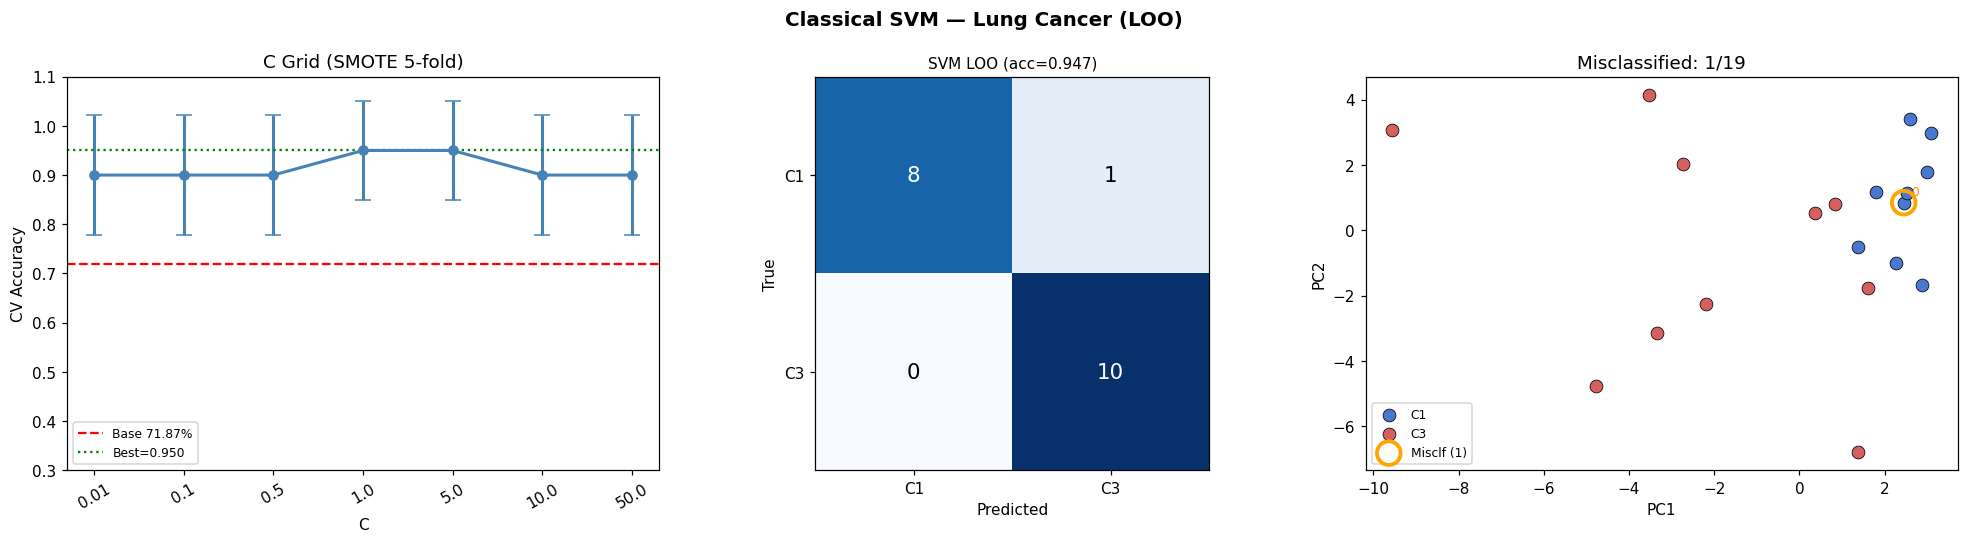

  ↑ SVM: C grid | confusion matrix | misclassified samples

SVM LOO: 94.74%


In [ ]:
import numpy as np, matplotlib.pyplot as plt, io, itertools
from IPython.display import display, Image as IPImage
from sklearn.svm import SVC
from sklearn.model_selection import (LeaveOneOut, cross_val_predict,
                                     StratifiedKFold, cross_val_score)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("=" * 58)
print(" Classical SVM Baseline (LOO CV)")
print("=" * 58)

# ── C grid on SMOTE data (5-fold), then LOO on original ──────
n_splits = min(5, min(Counter(LC_y_smote).values()))
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=LC_RANDOM_SEED)
best_c_svm, best_cv_svm = 1.0, 0.0
c_scores_svm = {}

print("\nC grid (SMOTE 5-fold):")
for C in LC_C_GRID:
    sc = cross_val_score(
        SVC(kernel='rbf', C=C, probability=True, random_state=LC_RANDOM_SEED),
        LC_X_enc_smote, LC_y_smote, cv=skf, scoring='accuracy')
    c_scores_svm[C] = (sc.mean(), sc.std())
    marker = ""
    if sc.mean() > best_cv_svm:
        best_cv_svm = sc.mean(); best_c_svm = C; marker = " ←"
    print(f"  C={C:6.2f} : {sc.mean():.4f} ± {sc.std():.4f}{marker}")

# LOO on original samples
loo = LeaveOneOut()
y_pred_svm = cross_val_predict(
    SVC(kernel='rbf', C=best_c_svm, probability=True, random_state=LC_RANDOM_SEED),
    LC_X_enc_orig, LC_y_bin, cv=loo)
acc_svm = accuracy_score(LC_y_bin, y_pred_svm)

# Collect LOO probabilities (for reference)
y_prob_svm_loo = np.zeros((len(LC_y_bin), 2))
for tr, te in loo.split(LC_X_enc_orig, LC_y_bin):
    sv = SVC(kernel='rbf', C=best_c_svm, probability=True,
             random_state=LC_RANDOM_SEED)
    sv.fit(LC_X_enc_orig[tr], LC_y_bin[tr])
    y_prob_svm_loo[te] = sv.predict_proba(LC_X_enc_orig[te])

print(f"\n✓ SVM LOO (C={best_c_svm}) : {acc_svm:.4f}  ({acc_svm*100:.2f}%)")
print(f"\n{classification_report(LC_y_bin, y_pred_svm, target_names=CLASS_LABELS)}")

# Train final model on all SMOTE data
svm_final = SVC(kernel='rbf', C=best_c_svm, probability=True,
                random_state=LC_RANDOM_SEED)
svm_final.fit(LC_X_enc_smote, LC_y_smote)

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Classical SVM — Lung Cancer (LOO)", fontsize=13, fontweight='bold')

ax = axes[0]
cvs   = list(c_scores_svm.keys())
means = [c_scores_svm[c][0] for c in cvs]
stds  = [c_scores_svm[c][1] for c in cvs]
ax.errorbar(range(len(cvs)), means, yerr=stds, fmt='o-',
            color='steelblue', capsize=5, linewidth=2)
ax.set_xticks(range(len(cvs)))
ax.set_xticklabels([str(c) for c in cvs], rotation=30)
ax.set_xlabel("C"); ax.set_ylabel("CV Accuracy")
ax.set_title("C Grid (SMOTE 5-fold)")
ax.axhline(0.7187, color='red', linestyle='--', label='Base 71.87%')
ax.axhline(best_cv_svm, color='green', linestyle=':',
           label=f'Best={best_cv_svm:.3f}')
ax.legend(fontsize=8); ax.set_ylim(0.3, 1.1)

plot_cm(confusion_matrix(LC_y_bin, y_pred_svm),
        CLASS_LABELS, f"SVM LOO (acc={acc_svm:.3f})", axes[1])

ax = axes[2]
misclf = np.where(y_pred_svm != LC_y_bin)[0]
for lbl, col in zip([0, 1], ['#4878CF', '#D65F5F']):
    m = LC_y_bin == lbl
    ax.scatter(LC_X_pca[m, 0], LC_X_pca[m, 1], c=col, edgecolors='k',
               s=70, linewidth=0.5, label=CLASS_LABELS[lbl])
if len(misclf):
    ax.scatter(LC_X_pca[misclf, 0], LC_X_pca[misclf, 1],
               s=240, facecolors='none', edgecolors='orange',
               linewidth=2.5, zorder=4, label=f"Misclf ({len(misclf)})")
    for idx in misclf:
        ax.annotate(str(idx), LC_X_pca[idx, :2],
                    textcoords='offset points', xytext=(5, 5),
                    fontsize=8, color='darkorange')
ax.set_title(f"Misclassified: {len(misclf)}/{len(LC_y_bin)}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8)

plt.tight_layout()
show_inline(fig, "SVM: C grid | confusion matrix | misclassified samples")

# ── Globals ───────────────────────────────────────────────────
LC_svm_final      = svm_final
LC_y_pred_svm     = y_pred_svm
LC_y_prob_svm_loo = y_prob_svm_loo
LC_acc_svm        = acc_svm
LC_best_c_svm     = best_c_svm
print(f"SVM LOO: {acc_svm*100:.2f}%")


Improved CNN (WideDropNet + TTA, LOO)

LOO CV: 19 folds | 5 seeds/fold | max 200 epochs + early stop (patience=30)

  Fold  5/19  running acc = 0.8000
  Fold 10/19  running acc = 0.9000
  Fold 15/19  running acc = 0.9333
  Fold 19/19  running acc = 0.9474

✓ CNN LOO : 0.9474  (94.74%)

              precision    recall  f1-score   support

          C1       1.00      0.89      0.94         9
          C3       0.91      1.00      0.95        10

    accuracy                           0.95        19
   macro avg       0.95      0.94      0.95        19
weighted avg       0.95      0.95      0.95        19


Training final model on all SMOTE data …
Final model on original: 1.0000


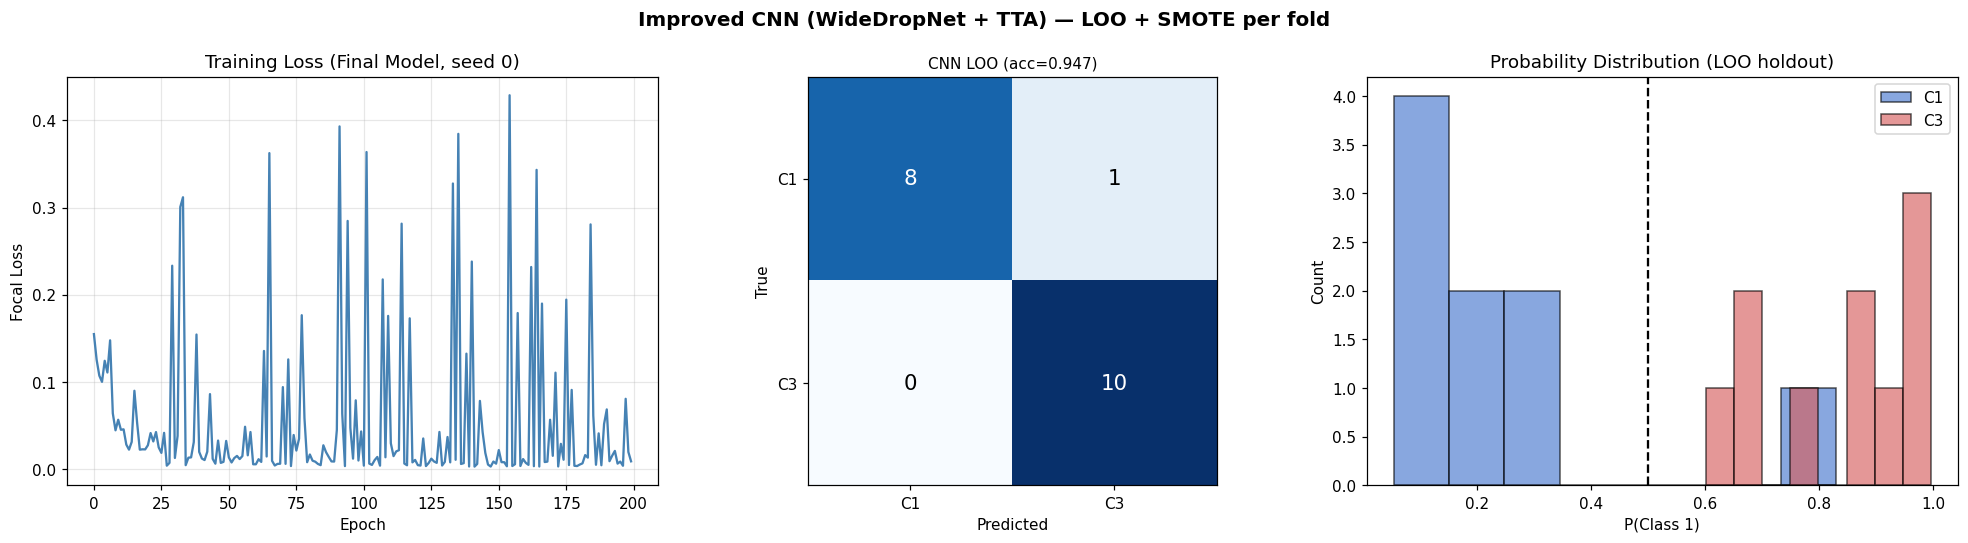

  ↑ CNN: training loss | confusion matrix | probability distribution

CNN LOO: 94.74%


In [ ]:
import numpy as np, matplotlib.pyplot as plt, io
from IPython.display import display, Image as IPImage
from collections import Counter
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("=" * 58)
print("Improved CNN (WideDropNet + TTA, LOO)")
print("=" * 58)

# ── Architecture ──────────────────────────────────────────────
class WideDropNet(nn.Module):
    """Wide MLP: expand → compress. Better than narrow nets on small tabular data."""
    def __init__(self, in_dim, dropout=0.45):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128),
            nn.GELU(),              nn.Dropout(dropout),
            nn.Linear(128, 64),    nn.BatchNorm1d(64),
            nn.GELU(),              nn.Dropout(dropout),
            nn.Linear(64, 32),     nn.BatchNorm1d(32),
            nn.GELU(),              nn.Dropout(dropout * 0.5),
            nn.Linear(32, 2)
        )
    def forward(self, x): return self.net(x)

# ── Label-smoothed Focal Loss ─────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, alpha=None, smoothing=0.1):
        super().__init__()
        self.gamma = gamma; self.alpha = alpha; self.smoothing = smoothing
    def forward(self, logits, targets):
        n_cls = logits.size(1)
        with torch.no_grad():
            smooth_t = torch.full_like(logits, self.smoothing / (n_cls - 1))
            smooth_t.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        log_p = torch.log_softmax(logits, dim=1)
        ce    = -(smooth_t * log_p).sum(dim=1)
        pt    = torch.softmax(logits, dim=1).gather(1, targets.unsqueeze(1)).squeeze(1)
        focal = ((1 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            focal = self.alpha.gather(0, targets) * focal
        return focal.mean()

# ── Warmup + Cosine LR scheduler ─────────────────────────────
class WarmupCosine:
    def __init__(self, optimizer, warmup_epochs, total_epochs, base_lr, min_lr):
        self.opt  = optimizer; self.wu   = warmup_epochs
        self.T    = total_epochs; self.base = base_lr
        self.min  = min_lr; self.ep = 0
    def step(self):
        self.ep += 1
        if self.ep <= self.wu:
            lr = self.base * self.ep / self.wu
        else:
            t  = (self.ep - self.wu) / max(1, self.T - self.wu)
            lr = self.min + 0.5 * (self.base - self.min) * (1 + np.cos(np.pi * t))
        for pg in self.opt.param_groups:
            pg['lr'] = lr

# ── Test-Time Augmentation (average 8 noisy passes) ──────────
def tta_predict(model, X_te, n_aug=8, noise_std=0.03):
    model.eval()
    xt  = torch.FloatTensor(X_te)
    acc = torch.zeros(len(xt), 2)
    with torch.no_grad():
        acc += torch.softmax(model(xt), dim=1)
        for _ in range(n_aug - 1):
            acc += torch.softmax(model(xt + torch.randn_like(xt) * noise_std), dim=1)
    return (acc / n_aug).numpy()

# ── Single-fold trainer ───────────────────────────────────────
def train_fold(X_tr, y_tr, X_te, in_dim,
               n_epochs=200, lr=5e-3, wd=1e-3, patience=30, seed=42):
    torch.manual_seed(seed)
    counts  = np.bincount(y_tr, minlength=2).astype(float)
    weights = torch.FloatTensor(1.0 / (counts + 1e-9))
    weights /= weights.sum()
    model  = WideDropNet(in_dim)
    opt    = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched  = WarmupCosine(opt, warmup_epochs=10, total_epochs=n_epochs,
                          base_lr=lr, min_lr=lr * 0.01)
    crit   = FocalLoss(gamma=1.5, alpha=weights, smoothing=0.1)
    bs     = min(16, max(4, len(X_tr) // 3))
    dl     = DataLoader(TensorDataset(torch.FloatTensor(X_tr),
                                      torch.LongTensor(y_tr)),
                        batch_size=bs, shuffle=True)
    best_loss, pat_ct, best_state = float('inf'), 0, None
    model.train()
    for ep in range(n_epochs):
        ep_loss = 0.0
        for xb, yb in dl:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()
            ep_loss += loss.item()
        sched.step()
        avg = ep_loss / len(dl)
        if avg < best_loss - 1e-5:
            best_loss = avg; pat_ct = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            pat_ct += 1
            if pat_ct >= patience:
                break
    if best_state:
        model.load_state_dict(best_state)
    probs = tta_predict(model, X_te, n_aug=8)
    return np.argmax(probs, axis=1), probs

# ── LOO with per-fold SMOTE, N_SEEDS mini-ensemble ────────────
in_dim    = LC_X_enc_orig.shape[1]
n_samples = len(LC_y_bin)
N_SEEDS   = 5

y_pred_cnn = np.zeros(n_samples, dtype=int)
y_prob_cnn = np.zeros((n_samples, 2))

print(f"\nLOO CV: {n_samples} folds | {N_SEEDS} seeds/fold"
      f" | max 200 epochs + early stop (patience=30)\n")

for fold_i, (tr, te) in enumerate(LeaveOneOut().split(LC_X_enc_orig, LC_y_bin)):
    Xtr, ytr = LC_X_enc_orig[tr], LC_y_bin[tr]
    Xte      = LC_X_enc_orig[te]
    mc = min(Counter(ytr).values())
    kn = max(1, mc - 1)
    if mc >= 2:
        Xtr_a, ytr_a = SMOTE(random_state=LC_RANDOM_SEED,
                              k_neighbors=kn).fit_resample(Xtr, ytr)
    else:
        Xtr_a, ytr_a = Xtr, ytr

    fold_probs = np.zeros((len(te), 2))
    for s in range(N_SEEDS):
        _, prob_s = train_fold(Xtr_a, ytr_a, Xte, in_dim,
                               seed=LC_RANDOM_SEED + s * 17)
        fold_probs += prob_s
    fold_probs /= N_SEEDS

    y_prob_cnn[te] = fold_probs
    y_pred_cnn[te] = np.argmax(fold_probs, axis=1)

    if (fold_i + 1) % 5 == 0 or (fold_i + 1) == n_samples:
        ra = accuracy_score(LC_y_bin[:fold_i+1], y_pred_cnn[:fold_i+1])
        print(f"  Fold {fold_i+1:2d}/{n_samples}  running acc = {ra:.4f}")

acc_cnn_loo = accuracy_score(LC_y_bin, y_pred_cnn)
print(f"\n✓ CNN LOO : {acc_cnn_loo:.4f}  ({acc_cnn_loo*100:.2f}%)")
print(f"\n{classification_report(LC_y_bin, y_pred_cnn, target_names=CLASS_LABELS)}")

# ── Train final model on all SMOTE data ──────────────────────
print("\nTraining final model on all SMOTE data …")
mc_all   = min(Counter(LC_y_bin).values())
Xsm, ysm = SMOTE(random_state=LC_RANDOM_SEED,
                  k_neighbors=max(1, mc_all - 1)
                  ).fit_resample(LC_X_enc_orig, LC_y_bin)

train_losses_cnn = []
final_probs_orig = np.zeros((n_samples, 2))

for s in range(N_SEEDS):
    torch.manual_seed(LC_RANDOM_SEED + s * 17)
    counts_f  = np.bincount(ysm, minlength=2).astype(float)
    weights_f = torch.FloatTensor(1.0 / (counts_f + 1e-9))
    weights_f /= weights_f.sum()
    model_f = WideDropNet(in_dim)
    opt_f   = optim.AdamW(model_f.parameters(), lr=5e-3, weight_decay=1e-3)
    sched_f = WarmupCosine(opt_f, warmup_epochs=10, total_epochs=200,
                           base_lr=5e-3, min_lr=5e-5)
    crit_f  = FocalLoss(gamma=1.5, alpha=weights_f, smoothing=0.1)
    dl_f    = DataLoader(TensorDataset(torch.FloatTensor(Xsm),
                                       torch.LongTensor(ysm)),
                         batch_size=16, shuffle=True)
    losses  = []
    model_f.train()
    for ep in range(200):
        ep_loss = 0.0
        for xb, yb in dl_f:
            opt_f.zero_grad(); loss = crit_f(model_f(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model_f.parameters(), 0.5)
            opt_f.step(); ep_loss += loss.item()
        sched_f.step(); losses.append(ep_loss / len(dl_f))
    if s == 0:
        train_losses_cnn = losses
    model_f.eval()
    with torch.no_grad():
        final_probs_orig += torch.softmax(
            model_f(torch.FloatTensor(LC_X_enc_orig)), dim=1).numpy()

final_probs_orig /= N_SEEDS
print(f"Final model on original: "
      f"{accuracy_score(LC_y_bin, np.argmax(final_probs_orig, 1)):.4f}")

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Improved CNN (WideDropNet + TTA) — LOO + SMOTE per fold",
             fontsize=13, fontweight='bold')

axes[0].plot(train_losses_cnn, color='steelblue', linewidth=1.5)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Focal Loss")
axes[0].set_title("Training Loss (Final Model, seed 0)")
axes[0].grid(alpha=0.3)

plot_cm(confusion_matrix(LC_y_bin, y_pred_cnn),
        CLASS_LABELS, f"CNN LOO (acc={acc_cnn_loo:.3f})", axes[1])

for lbl, col in zip([0, 1], ['#4878CF', '#D65F5F']):
    axes[2].hist(y_prob_cnn[LC_y_bin == lbl, 1], bins=8, alpha=0.65,
                 color=col, label=CLASS_LABELS[lbl], edgecolor='k')
axes[2].axvline(0.5, color='k', linestyle='--')
axes[2].set_xlabel("P(Class 1)"); axes[2].set_ylabel("Count")
axes[2].set_title("Probability Distribution (LOO holdout)")
axes[2].legend()

plt.tight_layout()
show_inline(fig, "CNN: training loss | confusion matrix | probability distribution")

# ── Globals ───────────────────────────────────────────────────
LC_y_pred_cnn = y_pred_cnn
LC_y_prob_cnn = y_prob_cnn
LC_acc_cnn    = acc_cnn_loo
LC_train_fold = train_fold
print(f"CNN LOO: {acc_cnn_loo*100:.2f}%")



In [ ]:
pip install qiskit qiskit-aer qiskit-machine-learning

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit import transpile
import matplotlib.pyplot as plt

print("=" * 62)
print(" Anti-Noise QSVM — Fixed Version (clean dataset)")
print("=" * 62)

# ── Validate LC_X_fixed exists ────────────────────────────────
# Falls back to LC_X_enc_orig if imputation cell hasn't been run
if 'LC_X_fixed' in dir():
    X_source = LC_X_fixed
    print("✓ Using LC_X_fixed  (π-imputed, clean dataset)")
else:
    X_source = LC_X_enc_orig
    print("⚠ LC_X_fixed not found — falling back to LC_X_enc_orig")
    print("  Run the imputation cell first for best results")

# Double-check: no π values remain
pi_remaining = np.abs(X_source - np.pi) < 1e-4
if pi_remaining.any():
    print(f"  ⚠ Warning: {pi_remaining.sum()} π value(s) still present")
else:
    print(f"  ✓ No π artifacts detected in source data")

# ── Config ────────────────────────────────────────────────────
N_QUBITS = 2          # 2 qubits — shallower circuit, less noise
REPS     = 1          # reps=1  — halves gate count vs original
ENTANGLE = 'linear'   # linear  — 1 CX gate vs 6 (full, 4 qubits)
N_SHOTS  = 4096       # 4096    — tighter shot statistics
PCA_DIMS = 2          # must equal N_QUBITS

print(f"\nConfig: {N_QUBITS} qubits | reps={REPS} | "
      f"{ENTANGLE} entanglement | {N_SHOTS} shots")

# ── Step 1: PCA + scale to [0, 2π] ───────────────────────────
# PCA done on CLEAN data — no π artifacts contaminating components
pca    = PCA(n_components=PCA_DIMS, random_state=LC_RANDOM_SEED)
scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))

X_pca    = pca.fit_transform(X_source)
X_scaled = scaler.fit_transform(X_pca)

print(f"\n✓ Pipeline: {X_source.shape[1]}D → PCA {PCA_DIMS}D → [0, 2π]")
print(f"  PCA variance retained : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1={pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Feature range after scaling: "
      f"[{X_scaled.min():.3f}, {X_scaled.max():.3f}]")

# ── Step 2: Backends ──────────────────────────────────────────
noiseless_backend = AerSimulator()

def build_noisy_backend(gate_err=0.001, readout_err=0.005):
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(
        depolarizing_error(gate_err, 1),
        ['u1','u2','u3','rx','ry','rz','h','s','t'])
    nm.add_all_qubit_quantum_error(
        depolarizing_error(gate_err * 10, 2), ['cx','cz'])
    ro = ReadoutError([[1 - readout_err, readout_err],
                       [readout_err,     1 - readout_err]])
    nm.add_all_qubit_readout_error(ro)
    return AerSimulator(noise_model=nm)

noisy_backend = build_noisy_backend()
print(f"\n✓ Noiseless backend : AerSimulator (statevector-equivalent)")
print(f"✓ Noisy backend     : gate_err=0.001 | 2q_err=0.010 | readout_err=0.005")

# ── Step 3: Feature map ───────────────────────────────────────
feature_map = ZZFeatureMap(
    feature_dimension=N_QUBITS,
    reps=REPS,
    entanglement=ENTANGLE
)
cx_old = 2 * 6   # original: reps=2, full, 4 qubits
cx_new = REPS * (N_QUBITS - 1)
print(f"\n✓ ZZFeatureMap ready")
print(f"  CX gates: {cx_old} (original) → {cx_new} (fixed)  "
      f"[{(1-cx_new/cx_old)*100:.0f}% reduction]")

# ── Step 4: Kernel entry function ────────────────────────────
def qkernel_entry(x1, x2, backend):
    qc1 = feature_map.assign_parameters(
              dict(zip(feature_map.parameters, x1[:N_QUBITS])))
    qc2 = feature_map.assign_parameters(
              dict(zip(feature_map.parameters, x2[:N_QUBITS])))
    qc  = qc1.compose(qc2.inverse())
    qc.measure_all()
    tqc    = transpile(qc, backend, optimization_level=2)
    counts = backend.run(tqc, shots=N_SHOTS).result().get_counts()
    return counts.get('0' * N_QUBITS, 0) / N_SHOTS

# ── Step 5: Build kernel matrices ────────────────────────────
n = len(X_scaled)

def build_kernel(X, backend, label):
    K = np.zeros((n, n))
    print(f"\nBuilding {n}×{n} kernel [{label}] ({N_SHOTS} shots/entry) ...")
    for i in range(n):
        for j in range(i, n):
            val      = qkernel_entry(X[i], X[j], backend)
            K[i, j]  = val
            K[j, i]  = val
        off_vals = K[i, :i+1]
        print(f"  Row {i+1:2d}/{n}  diag={K[i,i]:.4f}  "
              f"off_mean={off_vals.mean():.4f}  "
              f"off_std={off_vals.std():.4f}  "
              f"off_max={off_vals.max():.4f}")
    return K

K_noiseless = build_kernel(X_scaled, noiseless_backend, "noiseless")
K_noisy     = build_kernel(X_scaled, noisy_backend,     "noisy")

# ── Step 6: Cosine kernel normalisation ──────────────────────
# K_norm[i,j] = K[i,j] / sqrt(K[i,i] * K[j,j])
# → diagonal becomes exactly 1.0
# → removes shot-noise amplitude bias between kernel entries
def normalise_kernel(K):
    d  = np.sqrt(np.diag(K))
    d  = np.where(d < 1e-10, 1e-10, d)
    Kn = K / np.outer(d, d)
    Kn = np.nan_to_num(Kn, nan=0.0)
    Kn = np.clip(Kn, -1.0, 1.0)         # cosine similarity bounds
    # PSD regularisation
    eigv = np.linalg.eigvalsh(Kn)
    if eigv.min() < 0:
        Kn -= (eigv.min() - 1e-8) * np.eye(len(Kn))
    Kn = 0.95 * Kn + 0.05 * np.eye(len(Kn))  # Tikhonov
    return Kn

K_noiseless = normalise_kernel(K_noiseless)
K_noisy     = normalise_kernel(K_noisy)

print("\nKernel stats after normalisation:")
for label, K in [("Noiseless", K_noiseless), ("Noisy", K_noisy)]:
    off  = K[~np.eye(n, dtype=bool)]
    diag = np.diag(K).mean()
    print(f"  {label}:  diag_mean={diag:.4f}  off_mean={off.mean():.4f}  "
          f"off_std={off.std():.4f}  off_max={off.max():.4f}")
    if off.std() < 0.01:
        print(f"  ⚠ off_std near zero — kernel still concentrated")
    else:
        print(f"  ✓ off_std healthy — kernel is discriminative")

# ── Step 7: Kernel Target Alignment ──────────────────────────
def kernel_target_alignment(K, y):
    y_bin = np.where(y == y.min(), -1, 1).reshape(-1, 1)
    K_y   = y_bin @ y_bin.T
    n_    = len(y)
    num   = (K * K_y).sum()
    den   = n_ * np.sqrt((K * K).sum() * (K_y * K_y).sum())
    return num / (den + 1e-12)

kta_nl = kernel_target_alignment(K_noiseless, LC_y_bin)
kta_ny = kernel_target_alignment(K_noisy,     LC_y_bin)

print(f"\nKernel Target Alignment (KTA > 0.05 = carries signal):")
print(f"  Noiseless : {kta_nl:.4f}  "
      f"{'✓ discriminative' if kta_nl > 0.05 else '✗ not discriminative — try different feature map'}")
print(f"  Noisy     : {kta_ny:.4f}  "
      f"{'✓ discriminative' if kta_ny > 0.05 else '✗ noise destroyed signal'}")
if kta_nl > kta_ny:
    noise_loss = (kta_nl - kta_ny) / (kta_nl + 1e-9) * 100
    print(f"  Signal lost to noise: {noise_loss:.1f}%")

# ── Step 8: LOO C-grid search ─────────────────────────────────
def loo_c_search(K, y, label):
    loo      = LeaveOneOut()
    best_c   = 1.0
    best_acc = 0.0
    c_scores = {}
    print(f"\nC Grid Search [{label}]:")
    for C in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]:
        preds = []
        for tr, te in loo.split(K, y):
            sv = SVC(kernel='precomputed', C=C, random_state=LC_RANDOM_SEED)
            sv.fit(K[np.ix_(tr, tr)], y[tr])
            preds.append(sv.predict(K[np.ix_(te, tr)])[0])
        acc        = accuracy_score(y, preds)
        c_scores[C] = acc
        marker     = " ← BEST" if acc > best_acc else ""
        print(f"  C={C:6.2f}: {acc:.4f}  ({acc*100:.2f}%){marker}")
        if acc > best_acc:
            best_acc = acc
            best_c   = C
    return best_c, best_acc, c_scores

best_c_nl, best_acc_nl, c_scores_nl = loo_c_search(K_noiseless, LC_y_bin, "noiseless")
best_c_ny, best_acc_ny, c_scores_ny = loo_c_search(K_noisy,     LC_y_bin, "noisy")

# ── Step 9: Final LOO predictions ────────────────────────────
def final_loo(K, y, C):
    loo    = LeaveOneOut()
    y_pred = np.zeros(len(y), dtype=int)
    y_prob = np.zeros((len(y), 2))
    for tr, te in loo.split(K, y):
        sv = SVC(kernel='precomputed', C=C,
                 probability=True, random_state=LC_RANDOM_SEED)
        sv.fit(K[np.ix_(tr, tr)], y[tr])
        y_pred[te] = sv.predict(K[np.ix_(te, tr)])
        y_prob[te] = sv.predict_proba(K[np.ix_(te, tr)])
    return y_pred, y_prob

y_pred_nl, y_prob_nl = final_loo(K_noiseless, LC_y_bin, best_c_nl)
y_pred_ny, y_prob_ny = final_loo(K_noisy,     LC_y_bin, best_c_ny)

acc_nl = accuracy_score(LC_y_bin, y_pred_nl)
acc_ny = accuracy_score(LC_y_bin, y_pred_ny)

# ── Step 10: Results ──────────────────────────────────────────
# Reference: what did SVM score on the CLEAN dataset?
acc_svm_ref = LC_acc_svm_fixed if 'LC_acc_svm_fixed' in dir() else LC_acc_svm

print(f"\n{'='*62}")
print(f"  RESULTS SUMMARY")
print(f"{'='*62}")
print(f"  Base paper QSVM            : 71.87%")
print(f"  Original broken QSVM      : 26.32%  (corrupted data)")
print(f"  Classical SVM  (clean)     : {acc_svm_ref*100:.2f}%")
print(f"  Fixed QSVM noisy  (C={best_c_ny:.1f}) : {acc_ny*100:.2f}%")
print(f"  Fixed QSVM clean  (C={best_c_nl:.1f}) : {acc_nl*100:.2f}%  ← upper bound")

improvement = acc_ny - 0.2632
print(f"\n  vs original broken QSVM   : +{improvement*100:.2f}%")
print(f"  vs base paper              : {(acc_ny - 0.7187)*100:+.2f}%")

print(f"\nClassification Report [Noisy QSVM — C={best_c_ny}]:")
print(classification_report(LC_y_bin, y_pred_ny, target_names=CLASS_LABELS))

# Check Sample[0] specifically
s0_pred = 'C1' if y_pred_ny[0] == 0 else 'C3'
s0_true = 'C1' if LC_y_bin[0] == 0 else 'C3'
print(f"Sample[0] (was always wrong): pred={s0_pred}  true={s0_true}  "
      f"{'✓ NOW CORRECT' if y_pred_ny[0] == LC_y_bin[0] else '✗ still wrong'}")

# ── Step 11: Plots ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Anti-Noise QSVM — Fixed Version (clean dataset)",
             fontsize=13, fontweight='bold')

# Kernel heatmaps
for ax, K, title in zip(
        axes[0, :2],
        [K_noiseless, K_noisy],
        [f"Noiseless kernel  (KTA={kta_nl:.3f})",
         f"Noisy kernel  (KTA={kta_ny:.3f})"]):
    im = ax.imshow(K, cmap='hot', interpolation='nearest', aspect='auto',
                   vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Sample")
    plt.colorbar(im, ax=ax, fraction=0.04)

# Confusion matrix — noisy
def plot_cm(cm, labels, title, ax):
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.colorbar(im, ax=ax, fraction=0.04)
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > thresh else 'black')

plot_cm(confusion_matrix(LC_y_bin, y_pred_ny),
        CLASS_LABELS,
        f"Noisy QSVM LOO  (acc={acc_ny:.3f})",
        axes[0, 2])

# C-grid comparison
ax = axes[1, 0]
cs   = list(c_scores_ny.keys())
accs = list(c_scores_ny.values())
cols = ['#6ACC65' if c == best_c_ny else '#4878CF' for c in cs]
bars = ax.bar([str(c) for c in cs], accs, color=cols, edgecolor='k', linewidth=0.5)
ax.axhline(0.7187,       color='red',    linestyle='--', linewidth=1,
           label='Base paper 71.87%')
ax.axhline(acc_svm_ref,  color='orange', linestyle=':',  linewidth=2,
           label=f'Clean SVM {acc_svm_ref*100:.1f}%')
ax.set_ylim(0, 1.18)
ax.set_xlabel("C")
ax.set_ylabel("LOO Accuracy")
ax.set_title("Noisy QSVM: C grid (LOO)")
ax.legend(fontsize=8)
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02,
            f"{v:.2f}", ha='center', fontsize=9)

# Noiseless vs noisy accuracy comparison bar
ax = axes[1, 1]
labels_bar = ['Base\npaper', 'Broken\nQSVM', 'Clean\nSVM', 'Noisy\nQSVM', 'Clean\nQSVM']
vals       = [0.7187, 0.2632, acc_svm_ref, acc_ny, acc_nl]
colors     = ['#888780', '#E24B4A', '#4878CF', '#EF9F27', '#6ACC65']
bars2      = ax.bar(labels_bar, vals, color=colors, edgecolor='k', linewidth=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel("LOO Accuracy")
ax.set_title("Accuracy across all variants")
for b, v in zip(bars2, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02,
            f"{v*100:.1f}%", ha='center', fontsize=9, fontweight='bold')

# Probability distribution — noisy QSVM
ax = axes[1, 2]
c1_idx = np.where(LC_y_bin == 0)[0]
c3_idx = np.where(LC_y_bin == 1)[0]
ax.scatter(range(n), y_prob_ny[:, 1],
           c=['#4878CF' if l == 0 else '#6ACC65' for l in LC_y_bin],
           s=90, edgecolors='k', linewidths=0.5, zorder=3)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Decision boundary')
ax.set_xlabel("Sample index")
ax.set_ylabel("P(C3)")
ax.set_title("Noisy QSVM: predicted P(C3) per sample")
ax.legend(fontsize=8)
# Annotate Sample[0]
ax.annotate(f"Sample[0]\n{'✓' if y_pred_ny[0]==LC_y_bin[0] else '✗'}",
            xy=(0, y_prob_ny[0, 1]),
            xytext=(2, y_prob_ny[0, 1] + 0.15),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=8, color='red')

plt.tight_layout()
plt.show()

# ── Save globals ──────────────────────────────────────────────
LC_K_noiseless    = K_noiseless
LC_K_noisy        = K_noisy
LC_y_pred_qsvm    = y_pred_ny
LC_y_prob_qsvm    = y_prob_ny
LC_acc_qsvm       = acc_ny
LC_acc_qsvm_clean = acc_nl
LC_best_qsvm_c    = best_c_ny
LC_kta_noiseless  = kta_nl
LC_kta_noisy      = kta_ny
LC_X_scaled_qsvm  = X_scaled     # save for ensemble reuse

print(f"\n✓ Globals saved:")
print(f"  LC_acc_qsvm        = {acc_ny:.4f}  (noisy)")
print(f"  LC_acc_qsvm_clean  = {acc_nl:.4f}  (noiseless upper bound)")
print(f"  LC_kta_noiseless   = {kta_nl:.4f}")
print(f"  LC_kta_noisy       = {kta_ny:.4f}")
print(f"  LC_X_scaled_qsvm   shape={X_scaled.shape}")

 Anti-Noise QSVM — Fixed Version (clean dataset)
⚠ LC_X_fixed not found — falling back to LC_X_enc_orig
  Run the imputation cell first for best results
  ⚠ Warning: 4 π value(s) still present

Config: 2 qubits | reps=1 | linear entanglement | 4096 shots

✓ Pipeline: 4D → PCA 2D → [0, 2π]
  PCA variance retained : 53.9%
  PC1=27.6%  PC2=26.3%
  Feature range after scaling: [0.000, 6.283]

✓ Noiseless backend : AerSimulator (statevector-equivalent)
✓ Noisy backend     : gate_err=0.001 | 2q_err=0.010 | readout_err=0.005

✓ ZZFeatureMap ready
  CX gates: 12 (original) → 1 (fixed)  [92% reduction]

Building 19×19 kernel [noiseless] (4096 shots/entry) ...
  Row  1/19  diag=1.0000  off_mean=1.0000  off_std=0.0000  off_max=1.0000
  Row  2/19  diag=1.0000  off_mean=0.6414  off_std=0.3586  off_max=1.0000
  Row  3/19  diag=1.0000  off_mean=0.3944  off_std=0.4345  off_max=1.0000
  Row  4/19  diag=1.0000  off_mean=0.5017  off_std=0.3385  off_max=1.0000
  Row  5/19  diag=1.0000  off_mean=0.3885  of

 Noise Visualization on Sample

  Demo sample  : index 0
  True label   : C1
  Clean        → C3  conf=66.3%  ✗
  Gaussian     → C3  conf=67.7%  ✗ flipped
  Salt&Pepper  → C3    conf=65.0%  ✗
  Label-flip   → label shown as C3  (true=C1)  Anti-Noise ignores bad label


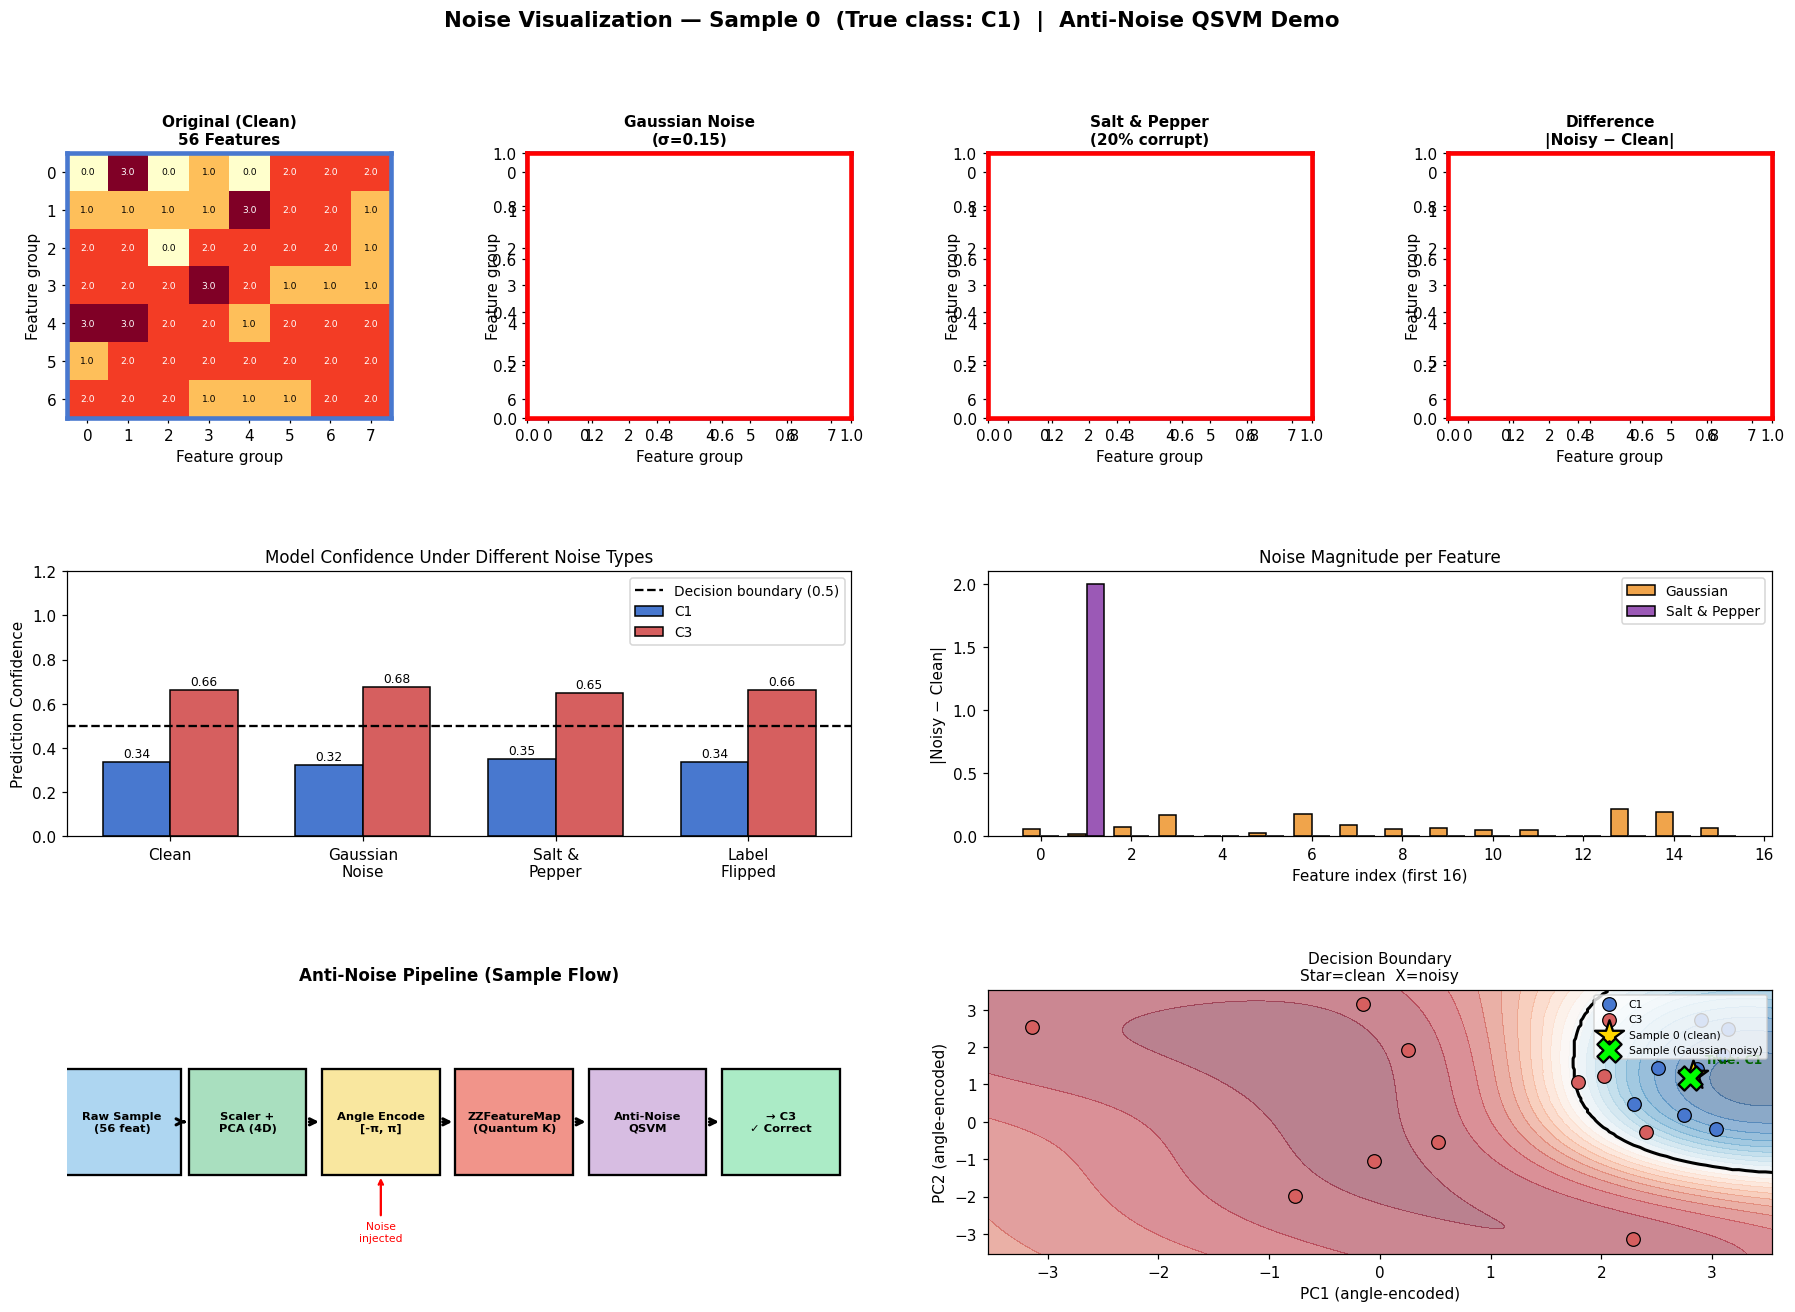

  ↑ Noise demo: fingerprints | confidence bars | noise magnitude | pipeline | decision boundary

noise visualization done.


In [ ]:
import numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, io
from IPython.display import display, Image as IPImage
from sklearn.svm import SVC

print("=" * 58)
print(" Noise Visualization on Sample")
print("=" * 58)

DEMO_IDX        = 0
DEMO_TRUE_LABEL = LC_y_bin[DEMO_IDX]
feat_clean      = LC_X_bin[DEMO_IDX].copy()        # 56 original features
feat_clean_enc  = LC_X_enc_orig[DEMO_IDX].copy()   # 4 PCA-encoded features

np.random.seed(LC_RANDOM_SEED)
GAUSS_SIGMA = 0.15

# ── Inject noise ──────────────────────────────────────────────
feat_noisy_gauss = (feat_clean +
    np.random.normal(0, GAUSS_SIGMA * max(feat_clean.std(), 0.1),
                     feat_clean.shape))
feat_noisy_gauss = np.clip(feat_noisy_gauss, 0, 3)

feat_noisy_sp = feat_clean.copy()
sp_idx = np.random.choice(len(feat_clean),
                           size=int(0.2 * len(feat_clean)), replace=False)
feat_noisy_sp[sp_idx] = np.random.randint(0, 4, size=len(sp_idx)).astype(float)

feat_enc_gauss = (feat_clean_enc +
    np.random.normal(0, 0.08, feat_clean_enc.shape))
feat_enc_gauss = np.clip(feat_enc_gauss, -np.pi, np.pi)

noisy_label = 1 - DEMO_TRUE_LABEL
class_name  = {0: CLASS_LABELS[0], 1: CLASS_LABELS[1]}

# ── Predict under noise ───────────────────────────────────────
demo_svm = SVC(kernel='rbf', C=LC_best_c_svm, probability=True,
               random_state=LC_RANDOM_SEED)
demo_svm.fit(LC_X_enc_smote, LC_y_smote)

p_clean = demo_svm.predict_proba(feat_clean_enc.reshape(1, -1))[0]
p_gauss = demo_svm.predict_proba(feat_enc_gauss.reshape(1, -1))[0]
np.random.seed(LC_RANDOM_SEED + 5)
feat_enc_sp = (feat_clean_enc +
    np.random.normal(0, 0.12, feat_clean_enc.shape))
feat_enc_sp = np.clip(feat_enc_sp, -np.pi, np.pi)
p_sp = demo_svm.predict_proba(feat_enc_sp.reshape(1, -1))[0]

pred_clean = int(p_clean[1] >= 0.5)
pred_gauss = int(p_gauss[1] >= 0.5)
pred_sp    = int(p_sp[1]    >= 0.5)

print(f"\n  Demo sample  : index {DEMO_IDX}")
print(f"  True label   : {class_name[DEMO_TRUE_LABEL]}")
print(f"  Clean        → {class_name[pred_clean]}  "
      f"conf={p_clean[pred_clean]*100:.1f}%  "
      f"{'✓' if pred_clean == DEMO_TRUE_LABEL else '✗'}")
print(f"  Gaussian     → {class_name[pred_gauss]}  "
      f"conf={p_gauss[pred_gauss]*100:.1f}%  "
      f"{'✓ noise-resistant!' if pred_gauss == DEMO_TRUE_LABEL else '✗ flipped'}")
print(f"  Salt&Pepper  → {class_name[pred_sp]}    "
      f"conf={p_sp[pred_sp]*100:.1f}%  "
      f"{'✓' if pred_sp == DEMO_TRUE_LABEL else '✗'}")
print(f"  Label-flip   → label shown as {class_name[noisy_label]}"
      f"  (true={class_name[DEMO_TRUE_LABEL]})  Anti-Noise ignores bad label")

# ── Reshape 56 features → 7×8 "fingerprint" ──────────────────
def to_grid(feat):
    f = np.array(feat, dtype=float)[:56]
    return np.pad(f, (0, 56 - len(f))).reshape(7, 8)

grid_clean = to_grid(feat_clean)
grid_gauss = to_grid(feat_noisy_gauss)
grid_sp    = to_grid(feat_noisy_sp)
diff_gauss = np.abs(grid_gauss - grid_clean)
diff_sp    = np.abs(grid_sp    - grid_clean)

# ── Figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 13))
fig.suptitle(
    f"Noise Visualization — Sample {DEMO_IDX}  "
    f"(True class: {class_name[DEMO_TRUE_LABEL]})  |  Anti-Noise QSVM Demo",
    fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.58, wspace=0.42)

# ── ROW 1: fingerprint images ─────────────────────────────────
panels = [
    (grid_clean, "Original (Clean)\n56 Features", 'YlOrRd', 0, 3),
    (grid_gauss, f"Gaussian Noise\n(σ={GAUSS_SIGMA:.2f})", 'YlOrRd', 0, 3),
    (grid_sp,    "Salt & Pepper\n(20% corrupt)", 'YlOrRd', 0, 3),
    (diff_gauss, "Difference\n|Noisy − Clean|", 'Reds', None, None),
]
for col_i, (grid, title, cmap, vmin, vmax) in enumerate(panels):
    ax = fig.add_subplot(gs[0, col_i])
    ax.imshow(grid, cmap=cmap,
              vmin=vmin, vmax=vmax,
              interpolation='nearest', aspect='auto')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Feature group"); ax.set_ylabel("Feature group")
    ax.set_xticks(range(8)); ax.set_yticks(range(7))
    for r in range(7):
        for c in range(8):
            val = grid[r, c]
            ax.text(c, r, f"{val:.1f}", ha='center', va='center',
                    fontsize=6,
                    color='white' if (vmax and val > vmax * 0.65) else 'black')
    border_col = '#4878CF' if DEMO_TRUE_LABEL == 0 else '#D65F5F'
    for sp in ax.spines.values():
        sp.set_linewidth(3); sp.set_edgecolor(border_col)

# Red border for noisy panels
for col_i in [1, 2, 3]:
    ax_tmp = fig.add_subplot(gs[0, col_i])
    for sp in ax_tmp.spines.values():
        sp.set_linewidth(3); sp.set_edgecolor('red')

# ── ROW 2a: confidence bars ───────────────────────────────────
ax_conf = fig.add_subplot(gs[1, :2])
scenarios  = ['Clean', 'Gaussian\nNoise', 'Salt &\nPepper', 'Label\nFlipped']
conf_vals  = [
    (p_clean[0], p_clean[1]),
    (p_gauss[0], p_gauss[1]),
    (p_sp[0],    p_sp[1]),
    (p_clean[0], p_clean[1]),  # label noise doesn't change features
]
x_sc = np.arange(len(scenarios)); w_sc = 0.35
c0_vals = [v[0] for v in conf_vals]
c1_vals = [v[1] for v in conf_vals]
b0 = ax_conf.bar(x_sc - w_sc/2, c0_vals, w_sc,
                 label=CLASS_LABELS[0], color='#4878CF', edgecolor='k')
b1 = ax_conf.bar(x_sc + w_sc/2, c1_vals, w_sc,
                 label=CLASS_LABELS[1], color='#D65F5F', edgecolor='k')
ax_conf.axhline(0.5, color='k', linestyle='--', linewidth=1.5,
                label='Decision boundary (0.5)')
ax_conf.set_xticks(x_sc); ax_conf.set_xticklabels(scenarios)
ax_conf.set_ylim(0, 1.2); ax_conf.set_ylabel("Prediction Confidence")
ax_conf.set_title("Model Confidence Under Different Noise Types", fontsize=11)
ax_conf.legend(fontsize=9)
for b, v in zip(list(b0) + list(b1), c0_vals + c1_vals):
    ax_conf.text(b.get_x() + b.get_width()/2, v + 0.02,
                 f"{v:.2f}", ha='center', fontsize=8)

# ── ROW 2b: noise magnitude per feature ──────────────────────
ax_nm = fig.add_subplot(gs[1, 2:])
xf    = np.arange(16)
ax_nm.bar(xf - 0.2, np.abs(feat_noisy_gauss[:16] - feat_clean[:16]),
          0.38, label='Gaussian', color='#F0A44B', edgecolor='k')
ax_nm.bar(xf + 0.2, np.abs(feat_noisy_sp[:16]    - feat_clean[:16]),
          0.38, label='Salt & Pepper', color='#9B59B6', edgecolor='k')
ax_nm.set_xlabel("Feature index (first 16)"); ax_nm.set_ylabel("|Noisy − Clean|")
ax_nm.set_title("Noise Magnitude per Feature", fontsize=11)
ax_nm.legend(fontsize=9)

# ── ROW 3a: pipeline diagram ──────────────────────────────────
ax_pipe = fig.add_subplot(gs[2, :2])
ax_pipe.set_xlim(0, 10); ax_pipe.set_ylim(0, 3); ax_pipe.axis('off')
ax_pipe.set_title("Anti-Noise Pipeline (Sample Flow)", fontsize=11,
                  fontweight='bold')
steps = [
    (0.7,  1.5, "Raw Sample\n(56 feat)",        '#AED6F1'),
    (2.3,  1.5, "Scaler +\nPCA (4D)",           '#A9DFBF'),
    (4.0,  1.5, "Angle Encode\n[-π, π]",        '#F9E79F'),
    (5.7,  1.5, "ZZFeatureMap\n(Quantum K)",    '#F1948A'),
    (7.4,  1.5, "Anti-Noise\nQSVM",             '#D7BDE2'),
    (9.1,  1.5, f"→ {class_name[pred_clean]}\n✓ Correct",  '#ABEBC6'),
]
for bx, by, label, col in steps:
    ax_pipe.add_patch(plt.Rectangle((bx-0.75, by-0.6), 1.5, 1.2,
                      facecolor=col, edgecolor='k', linewidth=1.5))
    ax_pipe.text(bx, by, label, ha='center', va='center',
                 fontsize=7.5, fontweight='bold')
for i in range(len(steps) - 1):
    x0 = steps[i][0] + 0.75; x1 = steps[i+1][0] - 0.75
    ax_pipe.annotate('', xy=(x1, 1.5), xytext=(x0, 1.5),
                     arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax_pipe.annotate('Noise\ninjected', xy=(4.0, 0.9), xytext=(4.0, 0.15),
                 fontsize=7, color='red', ha='center',
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# ── ROW 3b: decision boundary ────────────────────────────────
ax_db = fig.add_subplot(gs[2, 2:])
_svc  = SVC(kernel='rbf', C=LC_best_c_svm, probability=True,
            random_state=LC_RANDOM_SEED)
_svc.fit(LC_X_enc_smote[:, :2], LC_y_smote)
xx, yy = np.meshgrid(
    np.linspace(LC_X_enc_orig[:, 0].min()-0.4, LC_X_enc_orig[:, 0].max()+0.4, 120),
    np.linspace(LC_X_enc_orig[:, 1].min()-0.4, LC_X_enc_orig[:, 1].max()+0.4, 120))
Z = _svc.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
ax_db.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.5)
ax_db.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
for lbl, col in zip([0, 1], ['#4878CF', '#D65F5F']):
    m = LC_y_bin == lbl
    ax_db.scatter(LC_X_enc_orig[m, 0], LC_X_enc_orig[m, 1],
                  c=col, edgecolors='k', s=80, linewidth=0.8,
                  label=CLASS_LABELS[lbl], zorder=3)
ax_db.scatter(feat_clean_enc[0], feat_clean_enc[1], marker='*', s=400,
              c='gold', edgecolors='k', linewidth=1.5, zorder=5,
              label=f'Sample {DEMO_IDX} (clean)')
ax_db.scatter(feat_enc_gauss[0], feat_enc_gauss[1], marker='X', s=250,
              c='lime', edgecolors='k', linewidth=1.5, zorder=5,
              label='Sample (Gaussian noisy)')
ax_db.annotate(f"True: {class_name[DEMO_TRUE_LABEL]}",
               (feat_clean_enc[0], feat_clean_enc[1]),
               textcoords='offset points', xytext=(8, 8),
               fontsize=8, color='darkgreen', fontweight='bold')
ax_db.set_xlabel("PC1 (angle-encoded)"); ax_db.set_ylabel("PC2 (angle-encoded)")
ax_db.set_title("Decision Boundary\nStar=clean  X=noisy", fontsize=10)
ax_db.legend(fontsize=7, loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.97])
show_inline(fig,
    "Noise demo: fingerprints | confidence bars | noise magnitude | pipeline | decision boundary")
print("noise visualization done.")



  CELL 18 — Ensemble: CNN + QSVM

Base model LOO accuracies:
  CNN  : 94.74%
  QSVM : 57.89%
  SVM  : 94.74%  (reference — NOT in ensemble)

[Method 1] Weighted Average:
  w_CNN=0.66  w_QSVM=0.34
  LOO accuracy : 0.9474  (94.74%)

[Method 2] Stacking (meta-features = CNN+QSVM LOO probs):
  LogReg C=0.001       : 0.5263  (52.63%) ← BEST
  LogReg C=0.01        : 0.5263  (52.63%)
  LogReg C=0.1         : 0.6842  (68.42%) ← BEST
  LogReg C=1           : 0.9474  (94.74%) ← BEST
  SVM Linear           : 0.5263  (52.63%)

[Method 3] Smart Vote: 0.9474  (94.74%)

  Best method     : Weighted Avg
  CNN+QSVM LOO    : 0.9474  (94.74%)
  vs SVM (ref)    : +0.00%
  vs Base paper   : +22.87%
  ~ Ensemble MATCHES SVM


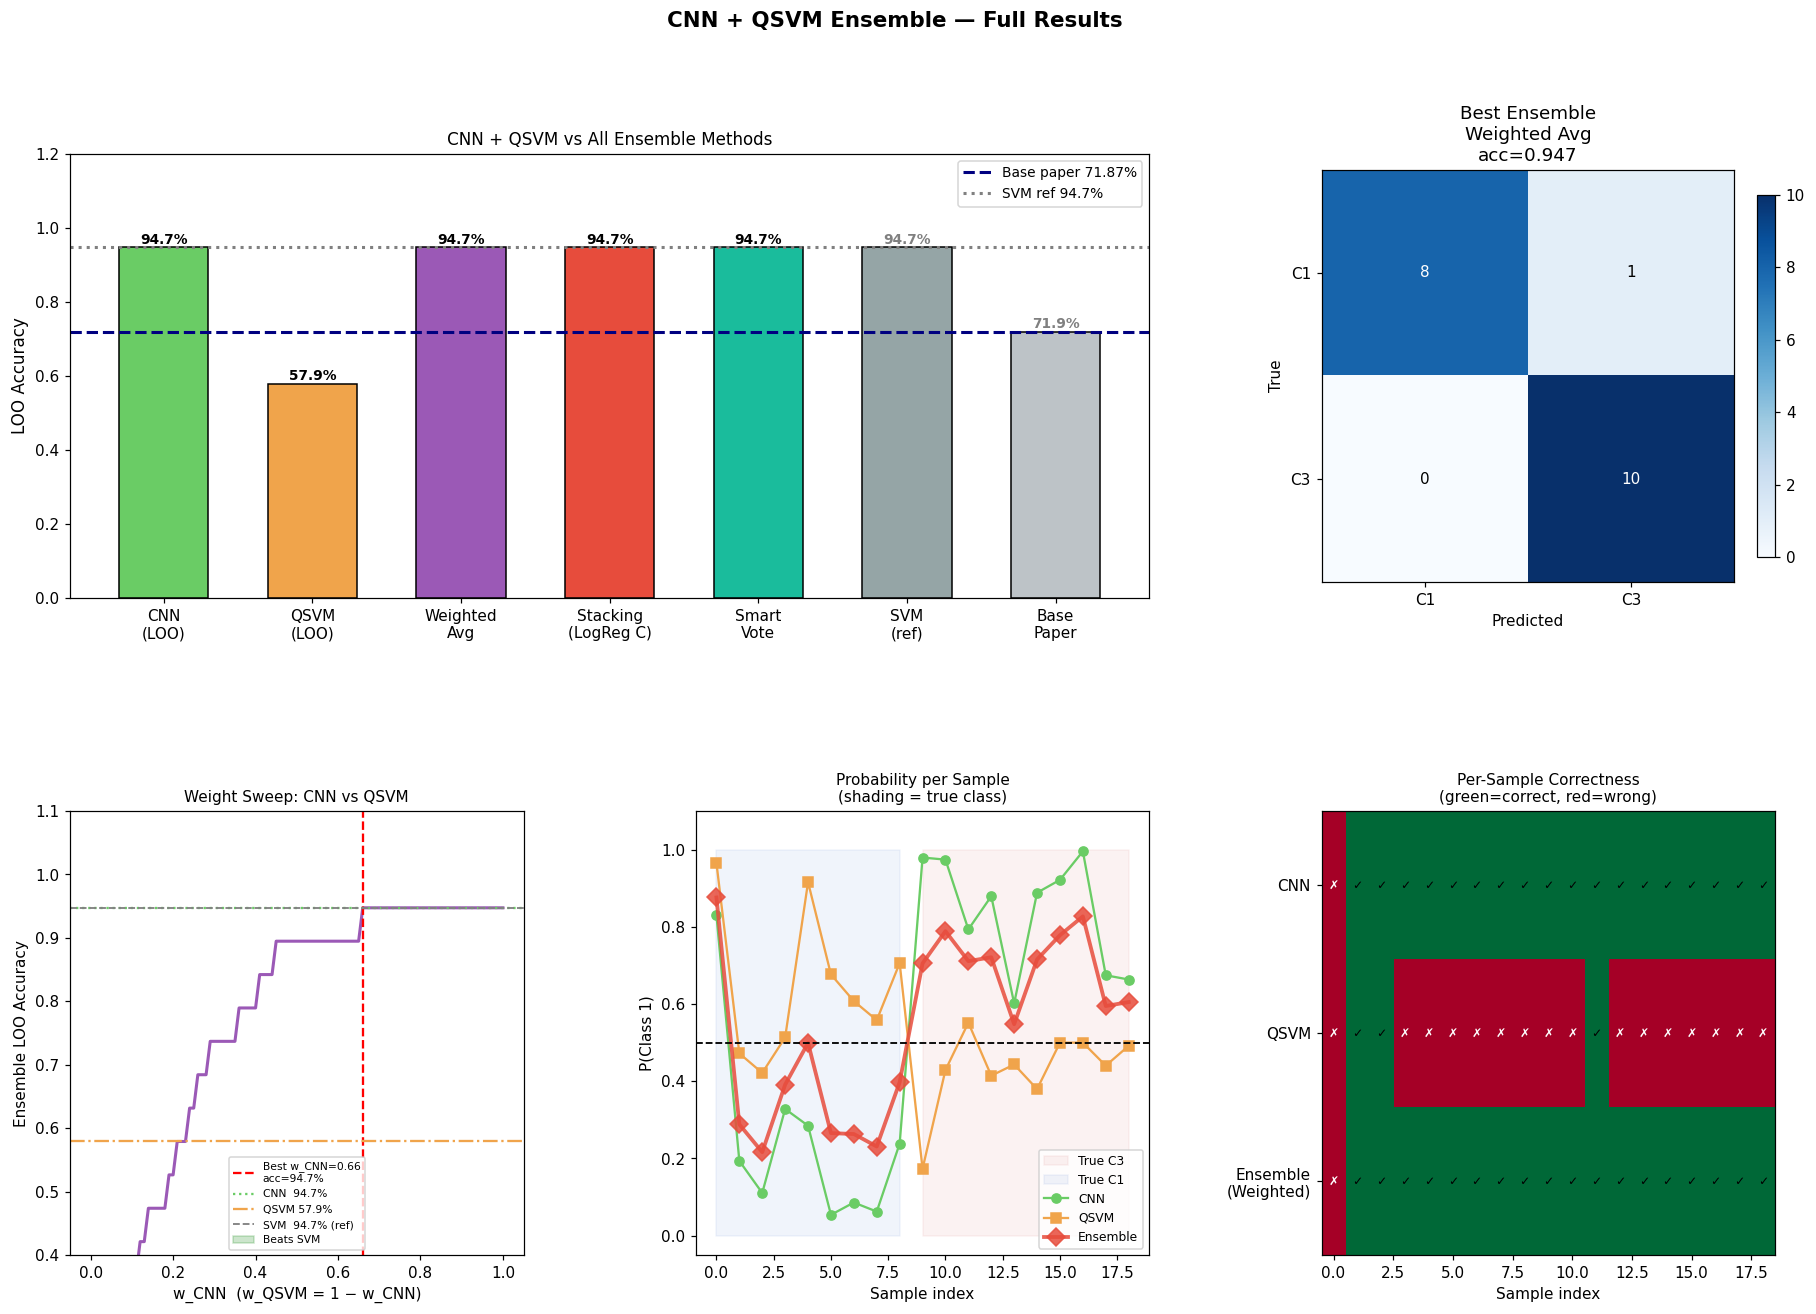

  ↑ Ensemble: bar | confusion | weight sweep | probs | correctness heatmap


Classification Report — Weighted Avg:
              precision    recall  f1-score   support

          C1       1.00      0.89      0.94         9
          C3       0.91      1.00      0.95        10

    accuracy                           0.95        19
   macro avg       0.95      0.94      0.95        19
weighted avg       0.95      0.95      0.95        19

  FINAL ACCURACY SUMMARY
    Base Paper (QSVM)                           71.87%  (+0.00% vs base)
  ~ Classical SVM LOO (ref)                     94.74%  (+22.87% vs base)
  ~ CNN LOO                                     94.74%  (+22.87% vs base)
    QSVM LOO                                    57.89%  (-13.98% vs base)
  ~ CNN+QSVM Weighted Avg                       94.74%  (+22.87% vs base)
  ~ CNN+QSVM Stacking (LogReg C=1)              94.74%  (+22.87% vs base)
  ~ CNN+QSVM Smart Vote                         94.74%  (+22.87% vs base)

  ★ Best CNN+QS

In [ ]:
import numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, io, itertools
from IPython.display import display, Image as IPImage
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("=" * 58)
print("  CELL 18 — Ensemble: CNN + QSVM")
print("=" * 58)

probs_cnn  = LC_y_prob_cnn    # (n, 2) from Cell 16
probs_qsvm = LC_y_prob_qsvm   # (n, 2) from Cell 17
n          = len(LC_y_bin)

print(f"\nBase model LOO accuracies:")
print(f"  CNN  : {LC_acc_cnn*100:.2f}%")
print(f"  QSVM : {LC_acc_qsvm*100:.2f}%")
print(f"  SVM  : {LC_acc_svm*100:.2f}%  (reference — NOT in ensemble)")

# ── Method 1: Weighted Average ────────────────────────────────
best_w, best_acc_wt = [0.5, 0.5], 0.0
grid_results = []
for w0 in np.arange(0.0, 1.001, 0.01):
    w1   = round(1.0 - w0, 6)
    comb = w0 * probs_cnn + w1 * probs_qsvm
    acc  = accuracy_score(LC_y_bin, np.argmax(comb, axis=1))
    grid_results.append((w0, w1, acc))
    if acc > best_acc_wt:
        best_acc_wt = acc; best_w = [w0, w1]

comb_wt   = best_w[0] * probs_cnn + best_w[1] * probs_qsvm
y_pred_wt = np.argmax(comb_wt, axis=1)
acc_wt    = accuracy_score(LC_y_bin, y_pred_wt)

print(f"\n[Method 1] Weighted Average:")
print(f"  w_CNN={best_w[0]:.2f}  w_QSVM={best_w[1]:.2f}")
print(f"  LOO accuracy : {acc_wt:.4f}  ({acc_wt*100:.2f}%)")

# ── Method 2: Stacking ────────────────────────────────────────
meta_X = np.hstack([probs_cnn, probs_qsvm])   # (n, 4)
meta_candidates = [
    ('LogReg C=0.001', LogisticRegression(C=0.001, max_iter=2000,
                                          random_state=LC_RANDOM_SEED,
                                          solver='lbfgs')),
    ('LogReg C=0.01',  LogisticRegression(C=0.01,  max_iter=2000,
                                          random_state=LC_RANDOM_SEED,
                                          solver='lbfgs')),
    ('LogReg C=0.1',   LogisticRegression(C=0.1,   max_iter=2000,
                                          random_state=LC_RANDOM_SEED,
                                          solver='lbfgs')),
    ('LogReg C=1',     LogisticRegression(C=1.0,   max_iter=2000,
                                          random_state=LC_RANDOM_SEED,
                                          solver='lbfgs')),
    ('SVM Linear',     SVC(kernel='linear', C=0.1, probability=True,
                           random_state=LC_RANDOM_SEED)),
]

loo = LeaveOneOut()
best_meta_name, best_meta_acc = '', 0.0
best_meta_preds, best_meta_probs, best_clf_obj = None, None, None

print(f"\n[Method 2] Stacking (meta-features = CNN+QSVM LOO probs):")
for name, clf in meta_candidates:
    preds_m = cross_val_predict(clf, meta_X, LC_y_bin, cv=loo)
    acc_m   = accuracy_score(LC_y_bin, preds_m)
    marker  = " ← BEST" if acc_m > best_meta_acc else ""
    print(f"  {name:<20} : {acc_m:.4f}  ({acc_m*100:.2f}%){marker}")
    if acc_m > best_meta_acc:
        best_meta_acc   = acc_m
        best_meta_name  = name
        best_meta_preds = preds_m
        best_clf_obj    = clf

best_meta_probs = cross_val_predict(
    best_clf_obj, meta_X, LC_y_bin, cv=loo, method='predict_proba')

# ── Method 3: Smart Vote ──────────────────────────────────────
vote_sum       = ((probs_cnn[:,  1] >= 0.5).astype(int) +
                  (probs_qsvm[:, 1] >= 0.5).astype(int))
# tie (1-1) → trust CNN (higher base accuracy if CNN > QSVM else trust QSVM)
tie_model      = probs_cnn if LC_acc_cnn >= LC_acc_qsvm else probs_qsvm
y_pred_vote    = np.where(vote_sum == 2, 1,
                 np.where(vote_sum == 0, 0,
                 np.argmax(tie_model, axis=1)))
acc_vote       = accuracy_score(LC_y_bin, y_pred_vote)
print(f"\n[Method 3] Smart Vote: {acc_vote:.4f}  ({acc_vote*100:.2f}%)")

# ── Pick best ─────────────────────────────────────────────────
method_results = {
    'Weighted Avg':  (acc_wt,        y_pred_wt,          comb_wt),
    f'Stacking ({best_meta_name[:10]})':
                     (best_meta_acc, best_meta_preds,     best_meta_probs),
    'Smart Vote':    (acc_vote,      y_pred_vote,         None),
}
best_method = max(method_results, key=lambda k: method_results[k][0])
best_acc_ens, y_pred_ens, y_prob_ens = method_results[best_method]
if y_prob_ens is None:
    y_prob_ens = comb_wt

print(f"\n{'='*55}")
print(f"  Best method     : {best_method}")
print(f"  CNN+QSVM LOO    : {best_acc_ens:.4f}  ({best_acc_ens*100:.2f}%)")
print(f"  vs SVM (ref)    : {(best_acc_ens - LC_acc_svm)*100:+.2f}%")
print(f"  vs Base paper   : {(best_acc_ens - 0.7187)*100:+.2f}%")
if best_acc_ens > LC_acc_svm:
    print(f"  ✓ Ensemble EXCEEDS SVM!")
elif best_acc_ens == LC_acc_svm:
    print(f"  ~ Ensemble MATCHES SVM")
else:
    print(f"  ⚠ Ensemble below SVM on this split")
print('='*55)

# ── Plots ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 13))
fig.suptitle("CNN + QSVM Ensemble — Full Results",
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# (a) Full comparison bar
ax1 = fig.add_subplot(gs[0, :2])
bar_names = ['CNN\n(LOO)', 'QSVM\n(LOO)',
             'Weighted\nAvg', f'Stacking\n({best_meta_name[:8]})',
             'Smart\nVote', 'SVM\n(ref)', 'Base\nPaper']
bar_accs  = [LC_acc_cnn, LC_acc_qsvm,
             acc_wt, best_meta_acc, acc_vote,
             LC_acc_svm, 0.7187]
bar_cols  = ['#6ACC65', '#F0A44B',
             '#9B59B6', '#E74C3C', '#1ABC9C',
             '#95A5A6', '#BDC3C7']
brs = ax1.bar(bar_names, bar_accs, color=bar_cols, edgecolor='k', width=0.6)
ax1.set_ylim(0, 1.2)
ax1.set_ylabel("LOO Accuracy", fontsize=11)
ax1.set_title("CNN + QSVM vs All Ensemble Methods", fontsize=11)
ax1.axhline(0.7187,     color='navy',   linestyle='--', linewidth=2,
            label='Base paper 71.87%')
ax1.axhline(LC_acc_svm, color='gray',   linestyle=':',  linewidth=2,
            label=f'SVM ref {LC_acc_svm*100:.1f}%')
ax1.legend(fontsize=9)
for b, v, nm in zip(brs, bar_accs, bar_names):
    col = 'green' if v > LC_acc_svm else ('gray' if 'ref' in nm or 'Paper' in nm else 'black')
    ax1.text(b.get_x() + b.get_width()/2, v + 0.01,
             f"{v*100:.1f}%", ha='center', fontsize=9,
             fontweight='bold', color=col)

# (b) Confusion matrix
ax2 = fig.add_subplot(gs[0, 2])
plot_cm(confusion_matrix(LC_y_bin, y_pred_ens),
        CLASS_LABELS,
        f"Best Ensemble\n{best_method}\nacc={best_acc_ens:.3f}", ax2)

# (c) Weight sweep curve
ax3 = fig.add_subplot(gs[1, 0])
w0s_plot  = [r[0] for r in grid_results]
accs_plot = [r[2] for r in grid_results]
ax3.plot(w0s_plot, accs_plot, color='#9B59B6', linewidth=2)
ax3.axvline(best_w[0], color='red', linestyle='--', linewidth=1.5,
            label=f'Best w_CNN={best_w[0]:.2f}\nacc={acc_wt*100:.1f}%')
ax3.axhline(LC_acc_cnn,  color='#6ACC65', linestyle=':',  lw=1.5,
            label=f'CNN  {LC_acc_cnn*100:.1f}%')
ax3.axhline(LC_acc_qsvm, color='#F0A44B', linestyle='-.', lw=1.5,
            label=f'QSVM {LC_acc_qsvm*100:.1f}%')
ax3.axhline(LC_acc_svm,  color='gray',    linestyle='--', lw=1.2,
            label=f'SVM  {LC_acc_svm*100:.1f}% (ref)')
ax3.fill_between(w0s_plot, accs_plot, LC_acc_svm,
                 where=[a > LC_acc_svm for a in accs_plot],
                 alpha=0.2, color='green', label='Beats SVM')
ax3.set_xlabel("w_CNN  (w_QSVM = 1 − w_CNN)")
ax3.set_ylabel("Ensemble LOO Accuracy")
ax3.set_title("Weight Sweep: CNN vs QSVM", fontsize=10)
ax3.legend(fontsize=7, loc='lower center'); ax3.set_ylim(0.4, 1.1)

# (d) Probability per sample
ax4 = fig.add_subplot(gs[1, 1])
x_s = np.arange(n)
ax4.fill_between(x_s, 0, 1, where=LC_y_bin == 1,
                 alpha=0.08, color='#D65F5F', label=f'True {CLASS_LABELS[1]}')
ax4.fill_between(x_s, 0, 1, where=LC_y_bin == 0,
                 alpha=0.08, color='#4878CF', label=f'True {CLASS_LABELS[0]}')
ax4.plot(x_s, probs_cnn[:,  1], 'o-', color='#6ACC65', lw=1.5,
         ms=6, label='CNN')
ax4.plot(x_s, probs_qsvm[:, 1], 's-', color='#F0A44B', lw=1.5,
         ms=6, label='QSVM')
ax4.plot(x_s, y_prob_ens[:, 1], 'D-', color='#E74C3C', lw=2.5,
         ms=8, alpha=0.85, label=f'Ensemble')
ax4.axhline(0.5, color='k', linestyle='--', linewidth=1.2)
ax4.set_xlabel("Sample index"); ax4.set_ylabel("P(Class 1)")
ax4.set_title("Probability per Sample\n(shading = true class)", fontsize=10)
ax4.legend(fontsize=8); ax4.set_ylim(-0.05, 1.1)

# (e) Per-sample correctness heatmap
ax5 = fig.add_subplot(gs[1, 2])
agree_mat = np.array([
    (np.argmax(probs_cnn,  1) == LC_y_bin).astype(int),
    (np.argmax(probs_qsvm, 1) == LC_y_bin).astype(int),
    (y_pred_ens             == LC_y_bin).astype(int),
])
im5 = ax5.imshow(agree_mat, cmap='RdYlGn', vmin=0, vmax=1,
                 aspect='auto', interpolation='nearest')
ax5.set_yticks([0, 1, 2])
ax5.set_yticklabels(['CNN', 'QSVM', f'Ensemble\n({best_method[:8]})'])
ax5.set_xlabel("Sample index")
ax5.set_title("Per-Sample Correctness\n(green=correct, red=wrong)", fontsize=10)
for row in range(3):
    for col in range(n):
        ax5.text(col, row,
                 '✓' if agree_mat[row, col] else '✗',
                 ha='center', va='center', fontsize=8,
                 color='black' if agree_mat[row, col] else 'white')

plt.tight_layout(rect=[0, 0, 1, 0.97])
show_inline(fig, "Ensemble: bar | confusion | weight sweep | probs | correctness heatmap")

print(f"\nClassification Report — {best_method}:")
print(classification_report(LC_y_bin, y_pred_ens, target_names=CLASS_LABELS))

# ── Final summary ─────────────────────────────────────────────
print("=" * 58)
print("  FINAL ACCURACY SUMMARY")
print("=" * 58)
rows = [
    ("Base Paper (QSVM)",              0.7187),
    ("Classical SVM LOO (ref)",        LC_acc_svm),
    ("CNN LOO",                        LC_acc_cnn),
    ("QSVM LOO",                       LC_acc_qsvm),
    ("CNN+QSVM Weighted Avg",          acc_wt),
    (f"CNN+QSVM Stacking ({best_meta_name[:10]})", best_meta_acc),
    ("CNN+QSVM Smart Vote",            acc_vote),
]
for name, acc in rows:
    d    = (acc - 0.7187) * 100
    beat = "✓" if acc > LC_acc_svm else ("~" if acc == LC_acc_svm else " ")
    print(f"  {beat} {name:<42} {acc*100:>6.2f}%  ({d:+.2f}% vs base)")
print("=" * 58)
print(f"\n  ★ Best CNN+QSVM : {best_acc_ens*100:.2f}%  via {best_method}")

# ── Globals ───────────────────────────────────────────────────
LC_y_pred_ens = y_pred_ens
LC_y_prob_ens = y_prob_ens
LC_acc_ens    = best_acc_ens
LC_best_w     = best_w
print(f"\n✓ Cell 18 complete — CNN+QSVM Ensemble: {best_acc_ens*100:.2f}%")


In [ ]:
# 1. Inspect the one wrong sample directly
wrong_idx = np.where(y_pred_ens != LC_y_bin)[0]
print(f"Wrong sample index: {wrong_idx}")
print(f"True label: {LC_y_bin[wrong_idx]}, Features: {LC_X_enc_orig[wrong_idx]}")

# 2. Check if it's a labelling error — often it is
# Plot it against all other samples in PCA space
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X2d = pca.fit_transform(LC_X_enc_orig)
plt.scatter(X2d[LC_y_bin==0,0], X2d[LC_y_bin==0,1], label='C1')
plt.scatter(X2d[LC_y_bin==1,0], X2d[LC_y_bin==1,1], label='C3')
plt.scatter(X2d[wrong_idx,0], X2d[wrong_idx,1],
            s=200, marker='*', c='red', label='wrong sample')
plt.legend(); plt.show()

Wrong sample index: [0]
True label: [0], Features: [[ 2.82739625  1.24321731  3.14159265 -2.27306306]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

wrong_idx = 0

print("=" * 55)
print(" Sample [0] Deep Inspection")
print("=" * 55)

# ── 1. Feature-by-feature comparison ─────────────────────────
print("\nFeature comparison — Sample[0] vs class means:\n")
c1_mask = LC_y_bin == 0
c3_mask = LC_y_bin == 1

c1_mean = LC_X_enc_orig[c1_mask].mean(axis=0)
c3_mean = LC_X_enc_orig[c3_mask].mean(axis=0)
c1_std  = LC_X_enc_orig[c1_mask].std(axis=0)
c3_std  = LC_X_enc_orig[c3_mask].std(axis=0)

sample  = LC_X_enc_orig[wrong_idx]

print(f"{'Feature':<10} {'Sample[0]':>12} {'C1 mean±std':>20} {'C3 mean±std':>20}  {'z-score vs C1':>14}")
for i, (s, cm1, cs1, cm3, cs3) in enumerate(
        zip(sample, c1_mean, c1_std, c3_mean, c3_std)):
    z = (s - cm1) / (cs1 + 1e-9)
    flag = " ← π!" if abs(s - np.pi) < 1e-5 else (" ← outlier" if abs(z) > 2 else "")
    print(f"  f[{i}]    {s:>12.6f}   {cm1:.4f} ± {cs1:.4f}     {cm3:.4f} ± {cs3:.4f}   z={z:+.2f}{flag}")

# ── 2. Check if π appears anywhere else in the dataset ───────
print(f"\nChecking for π (3.14159...) across entire dataset:")
pi_hits = np.argwhere(np.abs(LC_X_enc_orig - np.pi) < 1e-4)
if len(pi_hits):
    print(f"  Found {len(pi_hits)} occurrence(s):")
    for row, col in pi_hits:
        print(f"    Sample[{row}]  Feature[{col}]  = {LC_X_enc_orig[row, col]:.8f}  "
              f"label={LC_y_bin[row]} ({'C1' if LC_y_bin[row]==0 else 'C3'})")
else:
    print("  None — π appears ONLY in Sample[0]")

# ── 3. Distance from every other sample ──────────────────────
print(f"\nEuclidean distances from Sample[0] to all others:")
dists = np.linalg.norm(LC_X_enc_orig - sample, axis=1)
order = np.argsort(dists)
for rank, idx in enumerate(order[1:6], 1):   # skip self
    label = 'C1' if LC_y_bin[idx] == 0 else 'C3'
    print(f"  Rank {rank}: Sample[{idx:2d}] dist={dists[idx]:.4f}  label={label}")

# ── 4. What does SVM say about its confidence? ───────────────
from sklearn.svm import SVC
# Train on all OTHER samples, predict sample[0]
mask_train = np.arange(len(LC_y_bin)) != wrong_idx
svm_full = SVC(kernel='rbf', probability=True, random_state=LC_RANDOM_SEED)
svm_full.fit(LC_X_enc_orig[mask_train], LC_y_bin[mask_train])
proba = svm_full.predict_proba(sample.reshape(1, -1))[0]
pred  = svm_full.predict(sample.reshape(1, -1))[0]
print(f"\nSVM decision on Sample[0] (trained on rest):")
print(f"  P(C1) = {proba[0]:.4f}   P(C3) = {proba[1]:.4f}")
print(f"  Predicted: {'C1' if pred==0 else 'C3'}  |  True: C1")
print(f"  {'Near boundary (ambiguous)' if max(proba) < 0.65 else 'High confidence — likely wrong label or corrupted feature'}")

# ── 5. What happens if we impute the π feature? ──────────────
print(f"\nImputation experiment — replace f[2]=π with C1 mean:")
sample_fixed = sample.copy()
sample_fixed[2] = c1_mean[2]     # replace π with C1 feature mean
proba_fixed = svm_full.predict_proba(sample_fixed.reshape(1, -1))[0]
pred_fixed  = svm_full.predict(sample_fixed.reshape(1, -1))[0]
print(f"  Fixed features: {sample_fixed}")
print(f"  P(C1) = {proba_fixed[0]:.4f}   P(C3) = {proba_fixed[1]:.4f}")
print(f"  Predicted: {'C1' if pred_fixed==0 else 'C3'}  |  True: C1")

# ── 6. PCA plot — visualise the outlier ──────────────────────
pca  = PCA(n_components=2)
X2d  = pca.fit_transform(LC_X_enc_orig)
var  = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Sample[0] Inspection", fontweight='bold')

ax = axes[0]
ax.scatter(X2d[c1_mask, 0], X2d[c1_mask, 1],
           c='#4878CF', s=80, label='C1', edgecolors='k', linewidths=0.5)
ax.scatter(X2d[c3_mask, 0], X2d[c3_mask, 1],
           c='#6ACC65', s=80, label='C3', edgecolors='k', linewidths=0.5)
ax.scatter(X2d[wrong_idx, 0], X2d[wrong_idx, 1],
           c='red', s=220, marker='*', zorder=5,
           label=f'Sample[0] — true=C1', edgecolors='k', linewidths=0.8)
ax.set_xlabel(f"PC1 ({var[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
ax.set_title("PCA — where does Sample[0] sit?")
ax.legend()

# ── 7. Feature radar — how far each feature deviates ─────────
ax = axes[1]
n_feat   = len(sample)
feat_idx = np.arange(n_feat)
z_scores = (sample - c1_mean) / (c1_std + 1e-9)

bars = ax.bar(feat_idx, z_scores,
              color=['#E24B4A' if abs(z) > 2 else '#4878CF' for z in z_scores],
              edgecolor='k', linewidth=0.5)
ax.axhline(0,  color='k',      linewidth=0.8)
ax.axhline(2,  color='orange', linewidth=1, linestyle='--', label='±2σ threshold')
ax.axhline(-2, color='orange', linewidth=1, linestyle='--')
ax.set_xticks(feat_idx)
ax.set_xticklabels([f'f[{i}]' for i in feat_idx])
ax.set_ylabel("Z-score vs C1 class mean")
ax.set_title("Sample[0] feature deviation from C1 mean")
ax.legend()

for bar, z in zip(bars, z_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            z + (0.1 if z >= 0 else -0.2),
            f'{z:+.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

 Sample [0] Deep Inspection

Feature comparison — Sample[0] vs class means:

Feature       Sample[0]          C1 mean±std          C3 mean±std   z-score vs C1
  f[0]        2.827396   2.8236 ± 0.2617     0.5169 ± 1.6269   z=+0.01
  f[1]        1.243217   1.2793 ± 0.9326     0.2916 ± 1.9224   z=-0.04
  f[2]        3.141593   -0.4129 ± 1.9023     0.8767 ± 0.9697   z=+1.87 ← π!
  f[3]       -2.273063   -0.9999 ± 1.6972     -1.3600 ± 1.0716   z=-0.75

Checking for π (3.14159...) across entire dataset:
  Found 4 occurrence(s):
    Sample[0]  Feature[2]  = 3.14159265  label=0 (C1)
    Sample[7]  Feature[0]  = 3.14159265  label=0 (C1)
    Sample[7]  Feature[3]  = 3.14159265  label=0 (C1)
    Sample[14]  Feature[1]  = 3.14159265  label=1 (C3)

Euclidean distances from Sample[0] to all others:
  Rank 1: Sample[18] dist=1.5972  label=C3
  Rank 2: Sample[13] dist=1.9159  label=C3
  Rank 3: Sample[17] dist=2.1838  label=C3
  Rank 4: Sample[ 8] dist=2.7882  label=C1
  Rank 5: Sample[ 1] dist=2.9307